# Random Forest
## Topic: Customer Churn Prediction
### Reference: GeeksforGeeks + Original Notes

---

## 1. What is a Random Forest?

A **Random Forest** is a collection (ensemble) of many Decision Trees that work together to make a better prediction than any single tree alone.

> **GeeksforGeeks Definition:** Random Forest is a machine learning algorithm that uses many decision trees to make better predictions through an **ensemble approach** — combining results via **majority voting** (classification) or **averaging** (regression).

**Real-life analogy:**
```
You want to buy a new phone. You ask ONE friend → might get a biased opinion.
You ask 100 friends → take the majority opinion → much more reliable!

Random Forest = asking 100 different Decision Trees and taking a majority vote.
```

In Machine Learning, each tree is trained on **different data** and uses **different features** — so they disagree in different ways, and together they cancel out each other's mistakes.

---

## 2. Ensemble Learning — The Big Picture (GFG)

Random Forest is a type of **Ensemble Method**. Ensemble methods enhance predictive performance by combining multiple classifiers to balance their individual errors.

### Three Problems Ensembles Solve (GFG)

| Problem | What it means | How Ensemble fixes it |
|---------|--------------|----------------------|
| **Statistical** | Many models fit training data well — which one generalizes? | Averaging across models reduces generalization risk |
| **Computational** | Algorithm cannot find the single optimal solution efficiently | Combine multiple approximate solutions |
| **Representational** | True function not in the hypothesis space of any single learner | Ensemble can approximate complex target functions |

### Types of Ensemble Methods (GFG)

| Type | How it works | Reduces | sklearn class |
|------|-------------|---------|---------------|
| **Bagging** | Parallel trees on bootstrap samples — aggregate by vote/average | Variance | `RandomForestClassifier` |
| **Boosting** | Sequential trees — each corrects previous tree's errors | Bias | `GradientBoostingClassifier` |
| **Stacking** | Multiple base models + a meta-learner on top | Both | `StackingClassifier` |

**Key diversity principle (GFG):** Each base model should make **different types of errors** — even if individual models are weak, their combined errors cancel out.

---

## 3. Why Do We Need Random Forest?

| Problem with Decision Tree | How Random Forest Fixes It |
|---------------------------|---------------------------|
| Overfits easily (high variance) | Averaging many trees reduces variance |
| Unstable — small data change = completely different tree | Different trees disagree differently, ensemble is stable |
| Memorizes training noise | Noise affects different trees differently → cancels out |
| Single path of logic | Multiple diverse perspectives |

**Core insight:** Many imperfect models combined = one strong model.

---

## 4. Working of Random Forest — Step by Step (GFG)

```
STEP 1: Multiple Tree Creation
  → Generate N decision trees (n_estimators)
  → Each tree uses a DIFFERENT random bootstrap sample of the data
  → ~63% of original rows per tree (with replacement)

STEP 2: Random Feature Selection at each split
  → At every node split, consider only sqrt(total_features) random features
  → NOT all features — this creates diversity between trees
  → Best split is chosen from this random subset only

STEP 3: Individual Predictions
  → Every tree produces its own independent prediction
  → No tree sees what others predicted

STEP 4: Prediction Combination (Aggregation)
  → Classification: majority vote across all trees
  → Regression:     average of all tree outputs
  → Final answer is more accurate than any single tree
```

---

## 5. The Two Core Mechanisms

### Mechanism 1: Bagging (Bootstrap Aggregating)

**Bootstrap** = sampling WITH replacement

```
Original dataset: [A, B, C, D, E, F, G, H]  (8 samples)

Tree 1 trains on: [A, C, C, F, B, H, A, D]  ← some duplicates, some missing
Tree 2 trains on: [B, B, E, G, A, F, H, C]  ← different random sample
Tree 3 trains on: [D, A, G, G, C, E, B, F]  ← yet another random sample
```

Each tree sees a **different version** of the data → each tree makes different errors → combined they are more accurate.

On average, each tree sees ~63% of original samples. The remaining ~37% are called **Out-of-Bag (OOB)** samples — used for free validation!

### Mechanism 2: Feature Randomness (Random Subspace Method)

At every split, each tree considers only a **random subset of features** — NOT all features.

```
Dataset has 9 features: [F1, F2, F3, F4, F5, F6, F7, F8, F9]

Split in Tree 1 considers: [F2, F5, F8]  ← random 3 features
Split in Tree 2 considers: [F1, F4, F7]  ← different 3 features
Split in Tree 3 considers: [F3, F6, F9]  ← yet another 3

Default: sqrt(total_features) for classification  →  e.g., sqrt(9) = 3
```

**Why?** If one feature is very strong (dominant), every tree would use it at the top — all trees look the same → no diversity. Feature randomness forces trees to find other patterns.

---

## 6. Key Features and Assumptions (GFG)

### Functional Abilities
- Handles large, complex datasets efficiently
- Works for both **classification and regression** tasks
- Provides **feature importance rankings** automatically
- Reduces overfitting through ensemble averaging

### Data Requirements
- Requires **preprocessing for missing values** (sklearn does not handle natively)
- **No normalization or standardization needed** — unlike SVM, KNN
- Functions best with sufficient training data (enough to create diverse trees)

### Underlying Assumptions (GFG)
- Trees make **independent decisions** (ensured by bootstrap + feature randomness)
- **Random sampling and feature selection** reduce correlation between trees
- **Adequate data availability** enables diverse tree learning
- **Diversity improves accuracy** — trees that make different errors help each other

---

## 7. Terminology

| Term | Meaning |
|------|---------|
| Ensemble | A group of models working together |
| Bagging | Bootstrap sampling + aggregation (vote/average) |
| Bootstrap sample | Random sample WITH replacement from training data |
| OOB (Out-of-Bag) | Samples NOT in a tree's bootstrap — free validation set |
| Feature randomness | Each split sees only sqrt(n_features) random features |
| n_estimators | Number of trees in the forest |
| max_features | Features considered per split — default: sqrt(n_features) |
| Aggregation | How predictions combine — vote (classification) / mean (regression) |
| MDI | Mean Decrease in Impurity — built-in feature importance |
| Permutation Importance | Accuracy drop when feature shuffled — unbiased alternative to MDI |

---

## 8. Bagging vs Boosting — Head-to-Head (GFG)

```
BAGGING (Random Forest)              BOOSTING (XGBoost, AdaBoost, GBM)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Trees built in PARALLEL              Trees built SEQUENTIALLY

Each tree is INDEPENDENT             Each tree CORRECTS previous errors

Train on different bootstrap         Later trees focus MORE on samples
samples of the data                  that earlier trees got WRONG

Final = majority vote / average      Final = weighted sum of tree outputs

PRIMARY GOAL: Reduce VARIANCE        PRIMARY GOAL: Reduce BIAS

ROBUST — hard to overfit             CAN overfit — needs careful tuning

FAST — fully parallelizable          SLOWER — must train sequentially
```

| Property | Bagging | Boosting |
|----------|---------|----------|
| Tree order | Parallel | Sequential |
| Reduces | Variance | Bias |
| Overfitting risk | Low | Medium-High |
| Speed | Fast | Slower |
| Best when | Model overfits | Model underfits |

---

## 9. Bias-Variance Tradeoff in Random Forest

```
Single Decision Tree:                 Random Forest:

  Bias     → LOW  (fits training)       Bias     → LOW  (still fits well)
  Variance → HIGH (unstable, overfit)   Variance → LOW  (averaging reduces this)

  Training acc: 99%                     Training acc: 96%
  Test acc:     72%  ← BAD              Test acc:     93%  ← GOOD
```

Random Forest achieves **low bias AND low variance** — the best of both worlds.

**Why does averaging reduce variance?**
If each tree has variance σ², then the average of n independent trees has variance σ²/n.
Trees are not perfectly independent (share data) but the principle holds — more trees → lower variance.

---

## 10. Out-of-Bag (OOB) Score — Free Cross-Validation

**The Magic Trick:**
```
Tree 1 trained on: [A, C, C, F, B, H, A, D]
Tree 1 NEVER SAW:  [E, G]  ← these are OOB for Tree 1

→ Evaluate Tree 1 on [E, G] → unbiased estimate of its error!
```

For every sample, some trees never saw it → those trees give unbiased predictions.
**OOB Score = accuracy on these out-of-bag predictions** — essentially free cross-validation!

> **GFG:** OOB score is a reliable generalization performance estimate. With `oob_score=True`, sklearn computes this automatically during training — no extra computation needed.

**OOB vs Cross-Validation:**
| | OOB Score | k-Fold CV |
|-|-----------|----------|
| Extra training needed? | No — computed during training | Yes — re-trains k times |
| Speed | Instant | Slow (k× slower) |
| Reliability | Good approximation | Slightly more reliable |

---

## 11. Feature Importance in Random Forest

### Method 1: MDI — Mean Decrease in Impurity (built-in, GFG)

**Formula:**
```
Importance(feature X) = average over ALL trees of:
    sum over nodes where X was used:
        (n_samples_at_node / N_total) × impurity_decrease_at_node
```

- Fast — computed during training, no extra cost
- All scores sum to 1.0
- **GFG Caveat:** Biased toward high-cardinality features (numeric IDs, etc.)
  because they offer more possible split points

### Method 2: Permutation Importance (unbiased)

```
1. Train model → record baseline accuracy
2. Shuffle ALL values of feature X (break its relationship with target)
3. Re-evaluate accuracy on shuffled data
4. Importance(X) = baseline_accuracy - shuffled_accuracy

Large drop → feature was important
Small drop → feature was not important
```

---

## 12. Random Forest for Regression (GFG)

Same algorithm — different aggregation:

```
Classification  →  Final = MAJORITY VOTE of all trees
Regression      →  Final = MEAN of all tree numeric predictions

sklearn class:  RandomForestRegressor
criterion:      'squared_error' (MSE) — default
                'absolute_error' (MAE)
                'poisson' (for count data)
```

**Evaluation metrics for RF Regression (GFG):**
| Metric | Meaning |
|--------|--------|
| MSE | Average squared error — penalizes large errors more |
| RMSE | sqrt(MSE) — same unit as target, easier to read |
| MAE | Average absolute error — robust to outliers |
| R² | Proportion of variance explained — 1.0 is perfect, 0.0 = no better than mean |
| OOB Score | R² on out-of-bag samples — free validation |

**Important limitation (GFG):** Random Forest **cannot extrapolate** beyond training range.
→ Use Gradient Boosting when extrapolation is needed.

---

## 13. Overfitting in Random Forest

Random Forest is **much harder to overfit** than a single tree — but it CAN happen:

| Situation | Risk |
|-----------|------|
| Very noisy dataset with many irrelevant features | Medium |
| Very few trees (n_estimators=2) | High |
| Highly imbalanced classes | Medium |

**Unlike single trees:** Adding more trees (n_estimators) does NOT increase overfitting — it only helps until a plateau!

---

## 14. Advantages and Disadvantages (GFG)

### Advantages
| # | Advantage | Why it matters |
|---|-----------|----------------|
| 1 | High accuracy on large datasets | Ensemble reduces variance |
| 2 | Reduces overfitting | Much more robust than single tree |
| 3 | Handles high dimensionality | Works with hundreds of features |
| 4 | Built-in OOB validation | No need for separate validation set |
| 5 | Feature importance | Tells you which features matter |
| 6 | No feature scaling needed | Unlike SVM, KNN |
| 7 | Parallelizable | Each tree independent → fast on multi-core |
| 8 | Handles missing values (post-preprocessing) | Robust to incomplete data |

### Disadvantages (GFG)
| # | Disadvantage | Solution |
|---|-------------|----------|
| 1 | Not interpretable — black box | Use SHAP values or feature importance |
| 2 | Computationally expensive | Use n_jobs=-1, reduce n_estimators |
| 3 | High memory usage | Stores ALL trees in RAM |
| 4 | Cannot extrapolate beyond training range | Use Gradient Boosting |
| 5 | MDI biased toward high-cardinality features | Use permutation importance |
| 6 | Sensitive to class imbalance | Use class_weight='balanced' |

---

## 15. Real-World Applications (GFG)

| Domain | Use Case |
|--------|----------|
| Telecom | Customer churn prediction |
| Banking | Credit risk, loan default, fraud detection |
| Healthcare | Disease diagnosis, patient risk, drug discovery |
| E-commerce | Product recommendation, fraud detection |
| Finance | Stock movement, customer lifetime value |
| Real Estate | House price prediction (regression) |
| Manufacturing | Defect/anomaly detection |

---
# Implementation: Customer Churn Prediction
---

---
# SECTION A - Toy Example with Tree Diagrams + Simple Math

**4 customers. Goal: predict who will CHURN (leave) or STAY.**

| Customer | Tenure  | Monthly Bill | Churn?        |
|----------|---------|--------------|---------------|
| Alice    | 2 mo    | $95          | YES (churned) |
| Bob      | 5 mo    | $80          | YES (churned) |
| Carol    | 12 mo   | $60          | NO  (stayed)  |
| Dave     | 24 mo   | $50          | NO  (stayed)  |

**Run the code cell below** - it draws:
1. What Gini Impurity means visually
2. One decision tree with the math inside each node
3. Three trees (each trained on slightly different data)
4. A new customer walking through all 3 trees and voting
5. Regression: 3 trees predicting a number then averaging


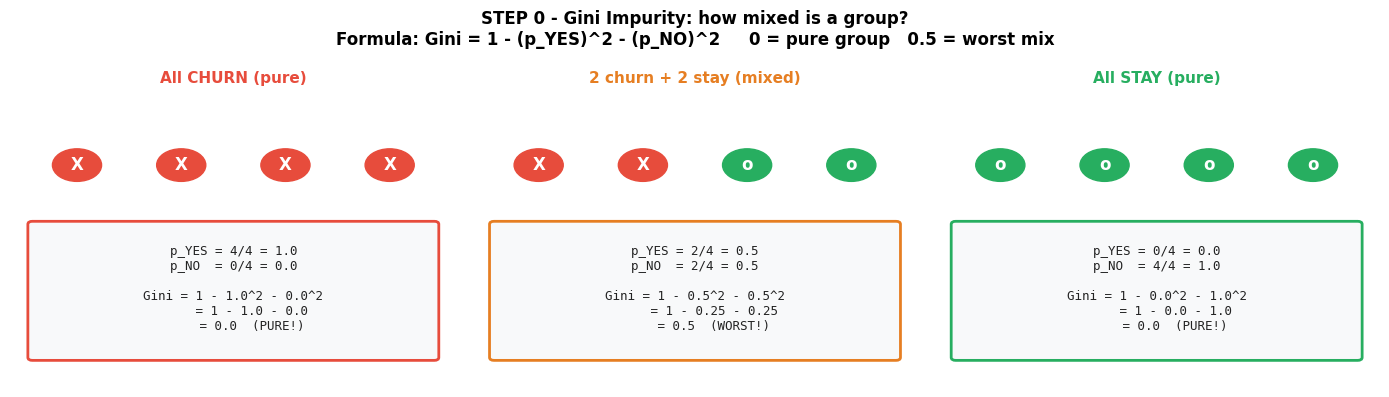

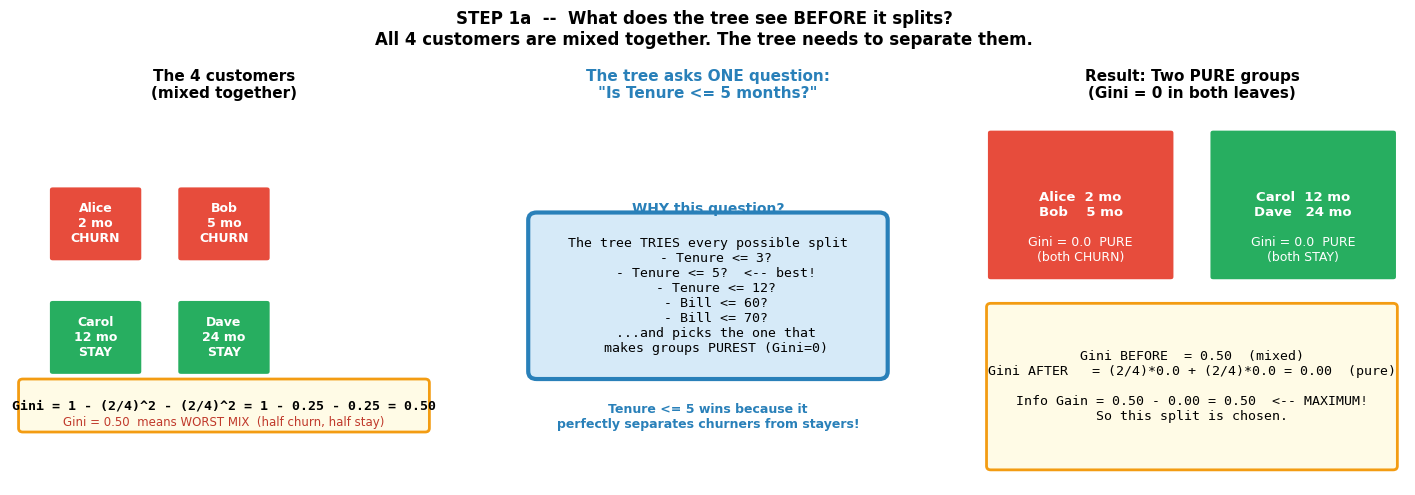

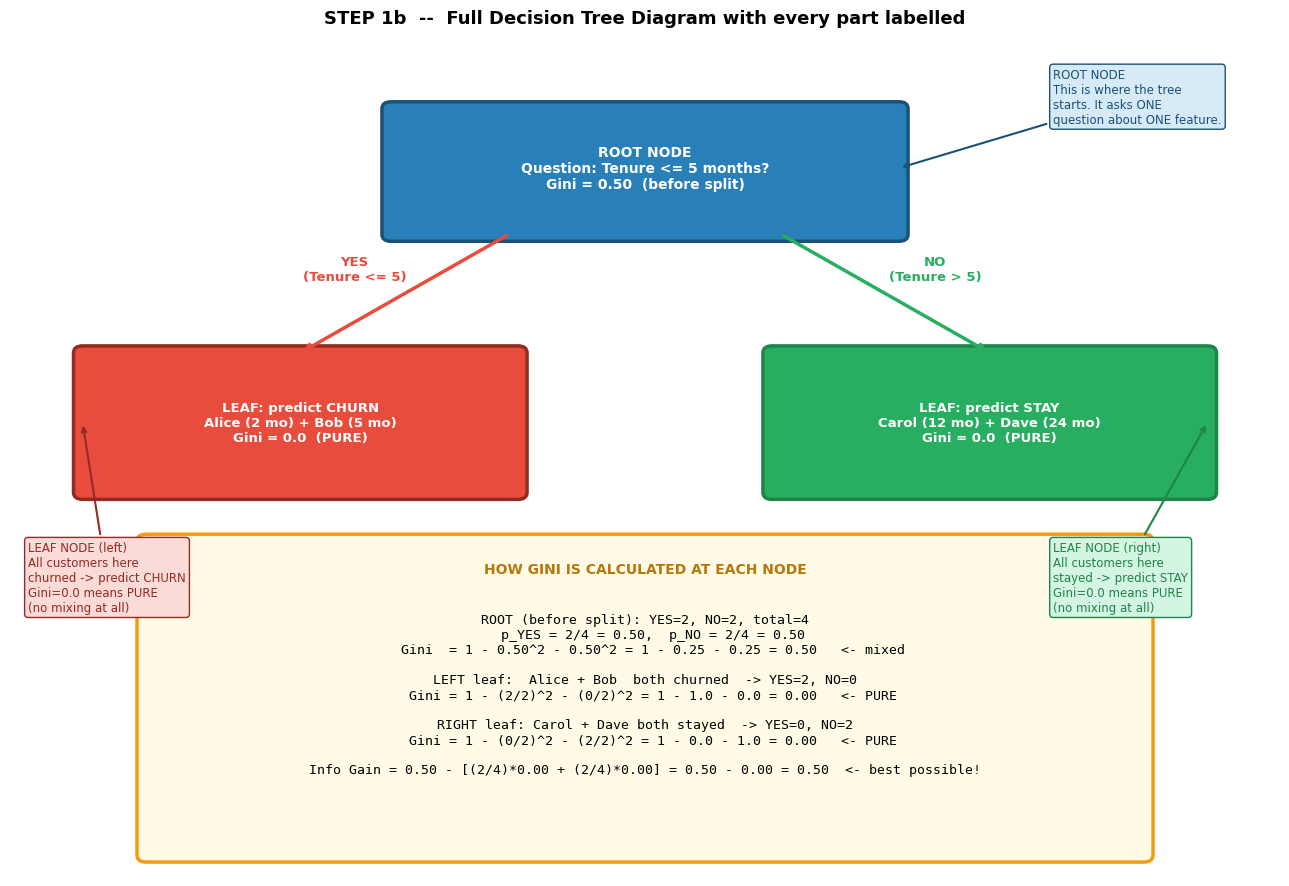

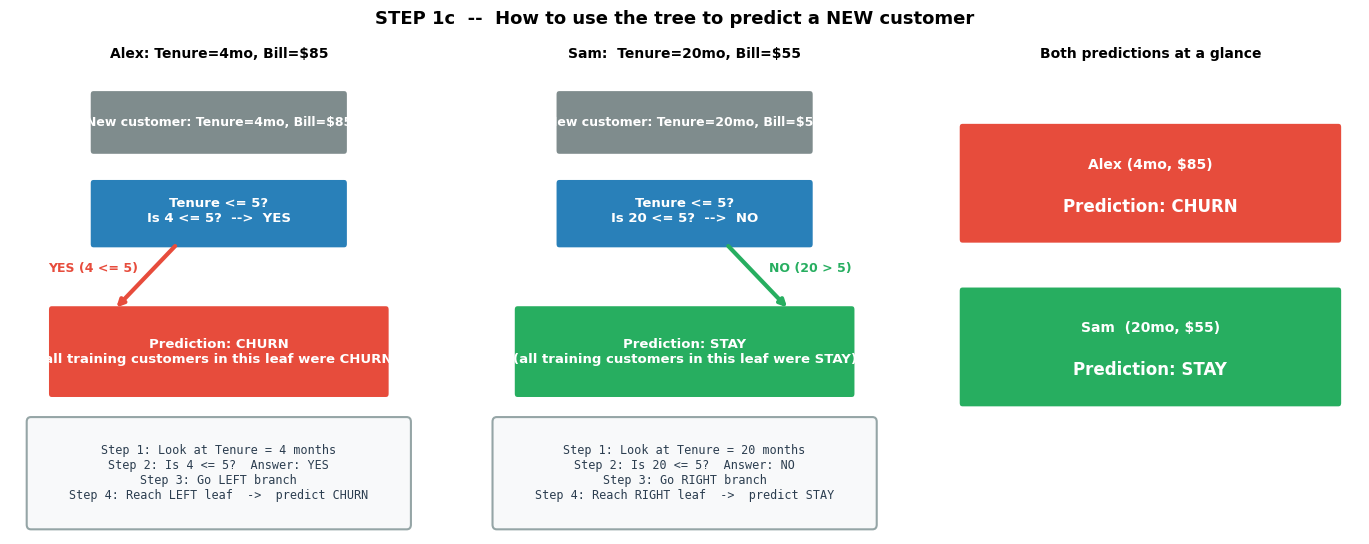

Figure 2 done. You saw:
  1a - the 4 customers before/after split, with Gini numbers
  1b - the full tree diagram with callout labels on every part
  1c - two new customers walking through the tree step by step


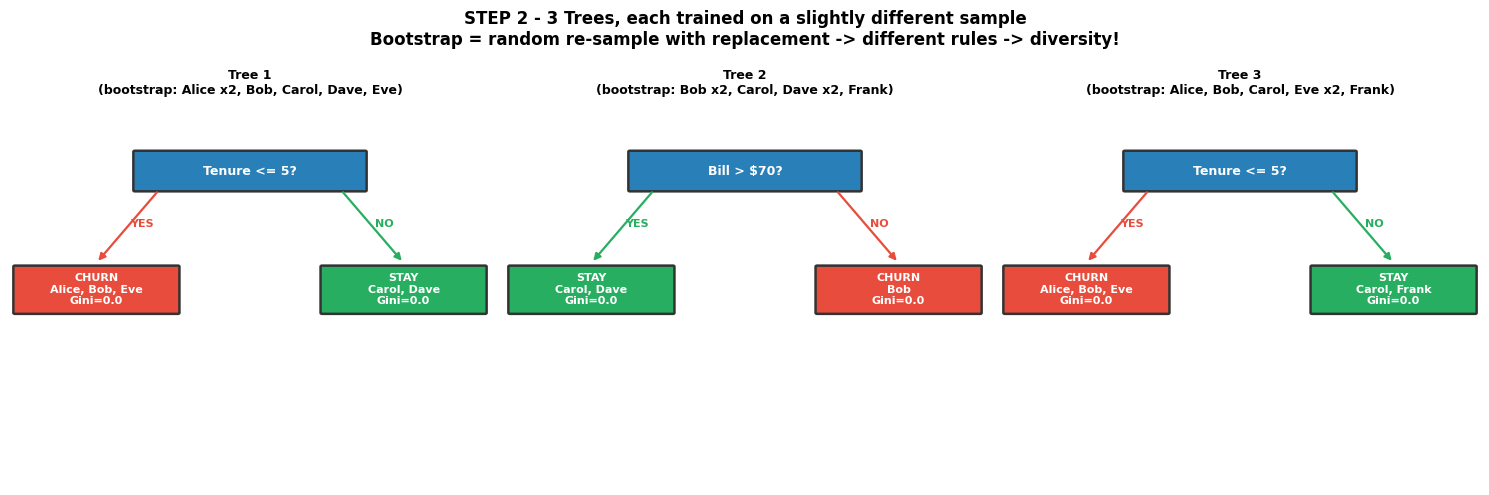

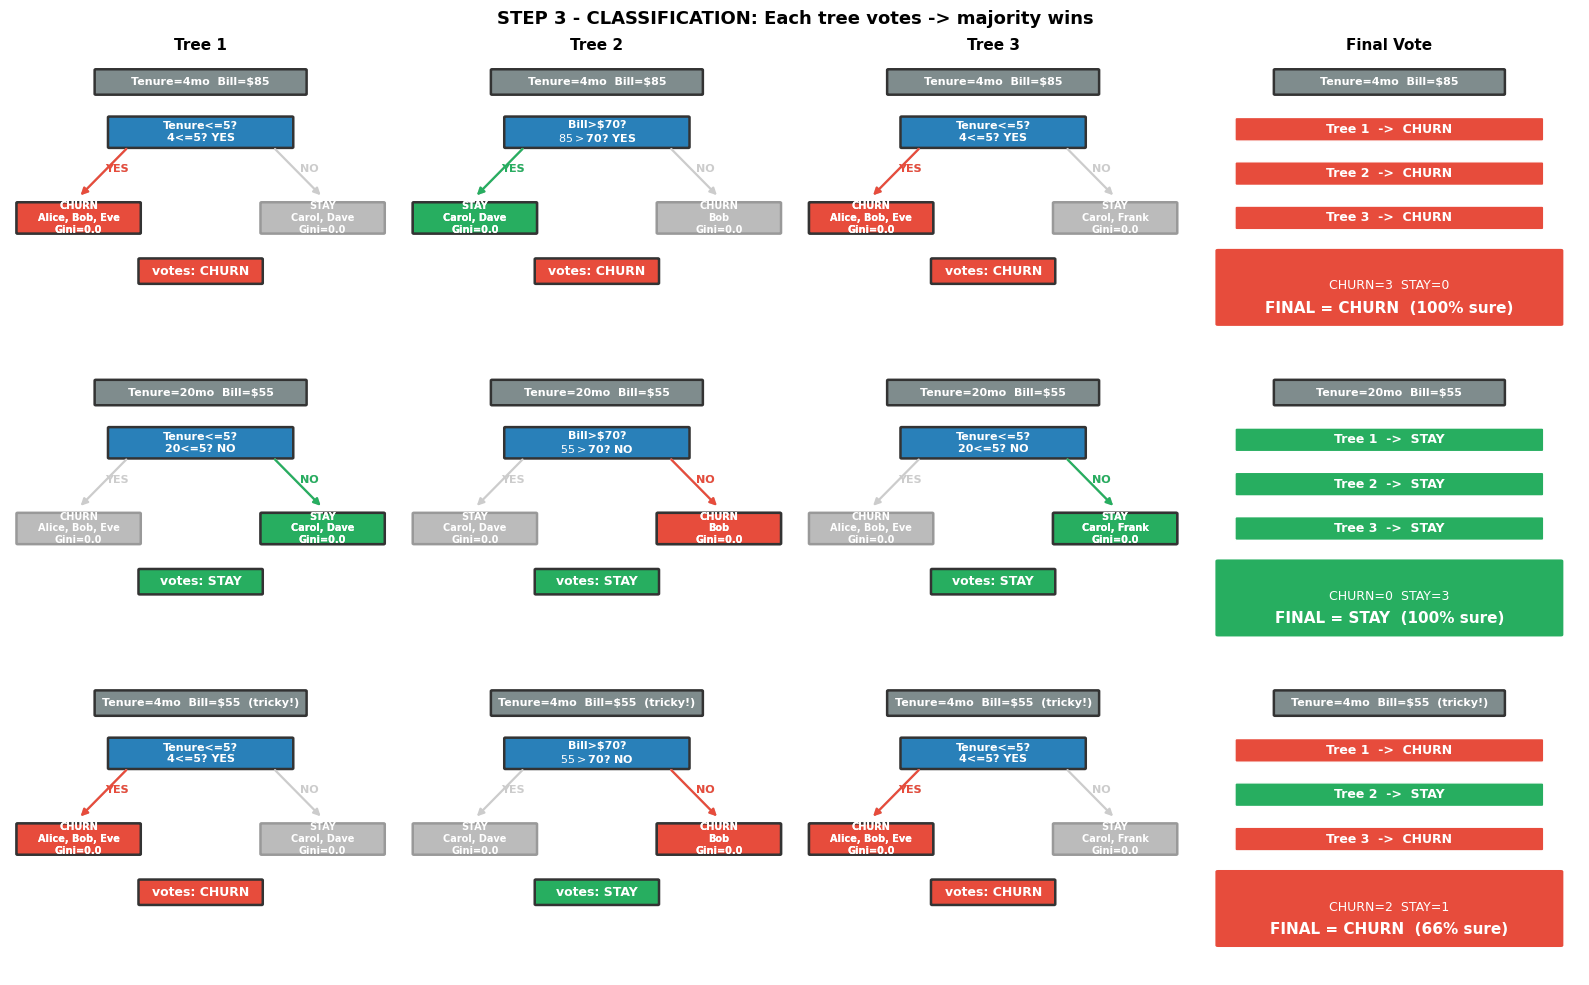

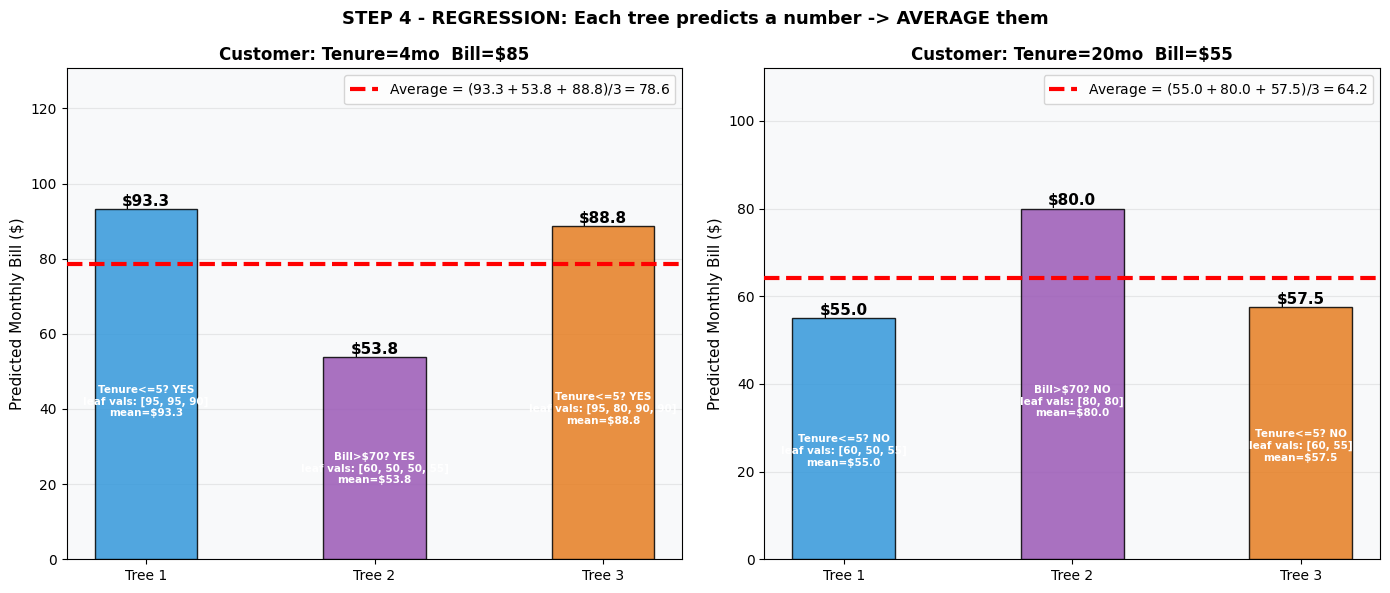

SUMMARY

Gini = 1 - p_YES^2 - p_NO^2
  0.0  -> pure leaf (all same class) -> STOP splitting
  0.5  -> 50/50 mix -> keep splitting
  Tree picks split that gives biggest Information Gain
  Info Gain = Gini_before - Gini_after

Classification (YES/NO):
  Each tree votes CHURN or STAY
  Count votes -> most votes = final answer
  Probability = winning votes / total trees

Regression (predict a number):
  Each tree predicts a number (leaf average from training)
  Add all predictions -> divide by number of trees
  Final = (Tree1 + Tree2 + Tree3) / 3


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# helper: draw a rounded box
def box(ax, x, y, w, h, text, fc, ec='#333', fs=9):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x-w/2, y-h/2), w, h, boxstyle='round,pad=0.03',
        linewidth=1.8, facecolor=fc, edgecolor=ec,
        transform=ax.transData, clip_on=False))
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fs, fontweight='bold',
            color='white' if fc not in ('#fffbe6','#f0f4ff','#f8f9fa') else '#222')

# helper: draw arrow with optional label
def arrow(ax, x1, y1, x2, y2, lbl='', lc='black'):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='-|>', color=lc, lw=1.6))
    if lbl:
        ax.text((x1+x2)/2+0.05, (y1+y2)/2, lbl,
                fontsize=8, color=lc, fontweight='bold')

CHURN_COL = '#e74c3c'
STAY_COL  = '#27ae60'
ROOT_COL  = '#2980b9'

# ==========================================================
# FIGURE 1  What is Gini Impurity?
# ==========================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    'STEP 0 - Gini Impurity: how mixed is a group?\n'
    'Formula: Gini = 1 - (p_YES)^2 - (p_NO)^2     '
    '0 = pure group   0.5 = worst mix',
    fontsize=12, fontweight='bold')

cases = [
    ('All CHURN (pure)', 4, 0, CHURN_COL,
     'p_YES = 4/4 = 1.0\np_NO  = 0/4 = 0.0\n\n'
     'Gini = 1 - 1.0^2 - 0.0^2\n     = 1 - 1.0 - 0.0\n     = 0.0  (PURE!)'),
    ('2 churn + 2 stay (mixed)', 2, 2, '#e67e22',
     'p_YES = 2/4 = 0.5\np_NO  = 2/4 = 0.5\n\n'
     'Gini = 1 - 0.5^2 - 0.5^2\n     = 1 - 0.25 - 0.25\n     = 0.5  (WORST!)'),
    ('All STAY (pure)', 0, 4, STAY_COL,
     'p_YES = 0/4 = 0.0\np_NO  = 4/4 = 1.0\n\n'
     'Gini = 1 - 0.0^2 - 1.0^2\n     = 1 - 0.0 - 1.0\n     = 0.0  (PURE!)'),
]
for ax, (title, ny, nn, col, calc) in zip(axes, cases):
    ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', color=col)
    total = ny + nn
    xs = np.linspace(1.5, 8.5, max(total,1))
    for i in range(ny):
        ax.add_patch(mpatches.Circle((xs[i],7.5),0.55,color=CHURN_COL,zorder=3))
        ax.text(xs[i],7.5,'X',ha='center',va='center',fontsize=12,
                color='white',fontweight='bold')
    for i in range(nn):
        ax.add_patch(mpatches.Circle((xs[ny+i],7.5),0.55,color=STAY_COL,zorder=3))
        ax.text(xs[ny+i],7.5,'o',ha='center',va='center',fontsize=12,
                color='white',fontweight='bold')
    ax.add_patch(mpatches.FancyBboxPatch((0.5,1.0),9.0,4.5,
        boxstyle='round,pad=0.1',facecolor='#f8f9fa',edgecolor=col,lw=2))
    ax.text(5, 3.3, calc, ha='center', va='center',
            fontsize=9, family='monospace', color='#222')
plt.tight_layout(); plt.show()

# ==========================================================
# FIGURE 2  One Decision Tree -- fully annotated
# ==========================================================

# ---- Sub-figure A: the 4 customers BEFORE any split -----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'STEP 1a  --  What does the tree see BEFORE it splits?\n'
    'All 4 customers are mixed together. The tree needs to separate them.',
    fontsize=12, fontweight='bold')

ax = axes[0]
ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
ax.set_title('The 4 customers\n(mixed together)', fontsize=11, fontweight='bold')
positions = [(2,7),(5,7),(2,4),(5,4)]
labels    = ['Alice\n2 mo\nCHURN','Bob\n5 mo\nCHURN',
             'Carol\n12 mo\nSTAY', 'Dave\n24 mo\nSTAY']
colors_p  = [CHURN_COL, CHURN_COL, STAY_COL, STAY_COL]
for (px,py), lbl, col in zip(positions, labels, colors_p):
    ax.add_patch(mpatches.FancyBboxPatch((px-1,py-1),2,1.8,
        boxstyle='round,pad=0.1',facecolor=col,edgecolor='white',lw=2))
    ax.text(px, py-0.1, lbl, ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
ax.add_patch(mpatches.FancyBboxPatch((0.3,1.5),9.4,1.2,
    boxstyle='round,pad=0.1',facecolor='#fffbe6',edgecolor='#f39c12',lw=2))
ax.text(5, 2.1,
    'Gini = 1 - (2/4)^2 - (2/4)^2 = 1 - 0.25 - 0.25 = 0.50',
    ha='center', va='center', fontsize=9.5, family='monospace', fontweight='bold')
ax.text(5, 1.65, 'Gini = 0.50  means WORST MIX  (half churn, half stay)',
    ha='center', va='center', fontsize=8.5, color='#c0392b')

ax = axes[1]
ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
ax.set_title('The tree asks ONE question:\n"Is Tenure <= 5 months?"',
             fontsize=11, fontweight='bold', color=ROOT_COL)
ax.add_patch(mpatches.FancyBboxPatch((1,3),8,4,
    boxstyle='round,pad=0.2', facecolor='#d6eaf8', edgecolor=ROOT_COL, lw=3))
ax.text(5, 7.2, 'WHY this question?', ha='center', fontsize=10,
        fontweight='bold', color=ROOT_COL)
ax.text(5, 5.0,
    'The tree TRIES every possible split\n'
    '  - Tenure <= 3?\n'
    '  - Tenure <= 5?  <-- best!\n'
    '  - Tenure <= 12?\n'
    '  - Bill <= 60?\n'
    '  - Bill <= 70?\n'
    '  ...and picks the one that\n'
    '  makes groups PUREST (Gini=0)',
    ha='center', va='center', fontsize=9.5, family='monospace')
ax.text(5, 1.8,
    'Tenure <= 5 wins because it\nperfectly separates churners from stayers!',
    ha='center', va='center', fontsize=9, color=ROOT_COL, fontweight='bold')

ax = axes[2]
ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
ax.set_title('Result: Two PURE groups\n(Gini = 0 in both leaves)',
             fontsize=11, fontweight='bold')
# YES group
ax.add_patch(mpatches.FancyBboxPatch((0.3,5.5),4.2,3.8,
    boxstyle='round,pad=0.1',facecolor=CHURN_COL,edgecolor='white',lw=2))
ax.text(2.4, 9.0, 'YES  (Tenure <= 5)', ha='center', fontsize=9,
        color=CHURN_COL, fontweight='bold')
ax.text(2.4, 7.4, 'Alice  2 mo\nBob    5 mo',
        ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')
ax.text(2.4, 6.2, 'Gini = 0.0  PURE\n(both CHURN)',
        ha='center', va='center', fontsize=9, color='white')
# NO group
ax.add_patch(mpatches.FancyBboxPatch((5.5,5.5),4.2,3.8,
    boxstyle='round,pad=0.1',facecolor=STAY_COL,edgecolor='white',lw=2))
ax.text(7.6, 9.0, 'NO  (Tenure > 5)', ha='center', fontsize=9,
        color=STAY_COL, fontweight='bold')
ax.text(7.6, 7.4, 'Carol  12 mo\nDave   24 mo',
        ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')
ax.text(7.6, 6.2, 'Gini = 0.0  PURE\n(both STAY)',
        ha='center', va='center', fontsize=9, color='white')
# Info gain
ax.add_patch(mpatches.FancyBboxPatch((0.3,0.5),9.4,4.2,
    boxstyle='round,pad=0.1',facecolor='#fffbe6',edgecolor='#f39c12',lw=2))
ax.text(5, 2.6,
    'Gini BEFORE  = 0.50  (mixed)\n'
    'Gini AFTER   = (2/4)*0.0 + (2/4)*0.0 = 0.00  (pure)\n\n'
    'Info Gain = 0.50 - 0.00 = 0.50  <-- MAXIMUM!\n'
    'So this split is chosen.',
    ha='center', va='center', fontsize=9.5, family='monospace')

plt.tight_layout(); plt.show()

# ---- Sub-figure B: the full tree diagram with callouts ------
fig, ax = plt.subplots(figsize=(13, 9))
ax.set_xlim(0, 14); ax.set_ylim(0, 12); ax.axis('off')
fig.suptitle(
    'STEP 1b  --  Full Decision Tree Diagram with every part labelled',
    fontsize=13, fontweight='bold')

# ---- ROOT NODE ----
ax.add_patch(mpatches.FancyBboxPatch((4.2,9.2),5.6,1.8,
    boxstyle='round,pad=0.1',facecolor=ROOT_COL,edgecolor='#1a5276',lw=2.5))
ax.text(7, 10.15,
    'ROOT NODE\nQuestion: Tenure <= 5 months?\nGini = 0.50  (before split)',
    ha='center', va='center', fontsize=10, color='white', fontweight='bold')

# callout A -- root node
ax.annotate('ROOT NODE\nThis is where the tree\nstarts. It asks ONE\nquestion about ONE feature.',
    xy=(9.8, 10.15), xytext=(11.5, 10.8),
    fontsize=8.5, color='#1a5276',
    arrowprops=dict(arrowstyle='->', color='#1a5276', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#d6eaf8', edgecolor='#1a5276'))

# ---- YES ARROW ----
ax.annotate('', xy=(3.2,7.5), xytext=(5.5,9.2),
    arrowprops=dict(arrowstyle='-|>', color=CHURN_COL, lw=2.5))
ax.text(3.8, 8.55, 'YES\n(Tenure <= 5)',
    ha='center', fontsize=9.5, color=CHURN_COL, fontweight='bold')

# ---- NO ARROW ----
ax.annotate('', xy=(10.8,7.5), xytext=(8.5,9.2),
    arrowprops=dict(arrowstyle='-|>', color=STAY_COL, lw=2.5))
ax.text(10.2, 8.55, 'NO\n(Tenure > 5)',
    ha='center', fontsize=9.5, color=STAY_COL, fontweight='bold')

# ---- LEFT LEAF (CHURN) ----
ax.add_patch(mpatches.FancyBboxPatch((0.8,5.5),4.8,2.0,
    boxstyle='round,pad=0.1',facecolor=CHURN_COL,edgecolor='#922b21',lw=2.5))
ax.text(3.2, 6.5,
    'LEAF: predict CHURN\nAlice (2 mo) + Bob (5 mo)\nGini = 0.0  (PURE)',
    ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')

# callout B -- left leaf
ax.annotate(
    'LEAF NODE (left)\nAll customers here\nchurned -> predict CHURN\nGini=0.0 means PURE\n(no mixing at all)',
    xy=(0.8, 6.5), xytext=(0.2, 3.8),
    fontsize=8.5, color='#922b21',
    arrowprops=dict(arrowstyle='->', color='#922b21', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fadbd8', edgecolor='#922b21'))

# ---- RIGHT LEAF (STAY) ----
ax.add_patch(mpatches.FancyBboxPatch((8.4,5.5),4.8,2.0,
    boxstyle='round,pad=0.1',facecolor=STAY_COL,edgecolor='#1e8449',lw=2.5))
ax.text(10.8, 6.5,
    'LEAF: predict STAY\nCarol (12 mo) + Dave (24 mo)\nGini = 0.0  (PURE)',
    ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')

# callout C -- right leaf
ax.annotate(
    'LEAF NODE (right)\nAll customers here\nstayed -> predict STAY\nGini=0.0 means PURE\n(no mixing at all)',
    xy=(13.2, 6.5), xytext=(11.5, 3.8),
    fontsize=8.5, color='#1e8449',
    arrowprops=dict(arrowstyle='->', color='#1e8449', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#d5f5e3', edgecolor='#1e8449'))

# ---- Gini formula box ----
ax.add_patch(mpatches.FancyBboxPatch((1.5,0.3),11.0,4.5,
    boxstyle='round,pad=0.1',facecolor='#fffbe6',edgecolor='#f39c12',lw=2.5))
ax.text(7, 4.35, 'HOW GINI IS CALCULATED AT EACH NODE',
    ha='center', fontsize=10, fontweight='bold', color='#b7770d')
ax.text(7, 2.6,
    'ROOT (before split): YES=2, NO=2, total=4\n'
    '  p_YES = 2/4 = 0.50,  p_NO = 2/4 = 0.50\n'
    '  Gini  = 1 - 0.50^2 - 0.50^2 = 1 - 0.25 - 0.25 = 0.50   <- mixed\n\n'
    'LEFT leaf:  Alice + Bob  both churned  -> YES=2, NO=0\n'
    '  Gini = 1 - (2/2)^2 - (0/2)^2 = 1 - 1.0 - 0.0 = 0.00   <- PURE\n\n'
    'RIGHT leaf: Carol + Dave both stayed  -> YES=0, NO=2\n'
    '  Gini = 1 - (0/2)^2 - (2/2)^2 = 1 - 0.0 - 1.0 = 0.00   <- PURE\n\n'
    'Info Gain = 0.50 - [(2/4)*0.00 + (2/4)*0.00] = 0.50 - 0.00 = 0.50  <- best possible!',
    ha='center', va='center', fontsize=9.5, family='monospace')

plt.tight_layout(); plt.show()

# ---- Sub-figure C: predict a new customer step by step ------
fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))
fig.suptitle(
    'STEP 1c  --  How to use the tree to predict a NEW customer',
    fontsize=13, fontweight='bold')

new_customers = [
    (4,  85, 'Alex: Tenure=4mo, Bill=$85'),
    (20, 55, 'Sam:  Tenure=20mo, Bill=$55'),
]

for ax, (tenure, bill, name) in zip(axes[:2], new_customers):
    goes_left = tenure <= 5
    pred = 'CHURN' if goes_left else 'STAY'
    pred_col = CHURN_COL if goes_left else STAY_COL
    branch_lbl = f'YES (4 <= 5)' if goes_left else f'NO (20 > 5)'
    branch_col = CHURN_COL if goes_left else STAY_COL

    ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
    ax.set_title(name, fontsize=10, fontweight='bold')

    # customer box
    ax.add_patch(mpatches.FancyBboxPatch((2,8.2),6,1.2,
        boxstyle='round,pad=0.1',facecolor='#7f8c8d',edgecolor='white',lw=2))
    ax.text(5, 8.8, f'New customer: Tenure={tenure}mo, Bill=${bill}',
        ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    # root
    ax.add_patch(mpatches.FancyBboxPatch((2,6.2),6,1.3,
        boxstyle='round,pad=0.1',facecolor=ROOT_COL,edgecolor='white',lw=2))
    ax.text(5, 6.9,
        f'Tenure <= 5?\nIs {tenure} <= 5?  -->  {"YES" if goes_left else "NO"}',
        ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')

    # arrow to chosen leaf
    ax.annotate('', xy=(2.5 if goes_left else 7.5, 4.8),
        xytext=(4 if goes_left else 6, 6.2),
        arrowprops=dict(arrowstyle='-|>', color=branch_col, lw=3))
    ax.text(2.0 if goes_left else 8.0, 5.6,
        branch_lbl, ha='center', fontsize=9, color=branch_col, fontweight='bold')

    # prediction leaf
    ax.add_patch(mpatches.FancyBboxPatch((1.0,3.0),8,1.8,
        boxstyle='round,pad=0.1',facecolor=pred_col,edgecolor='white',lw=2))
    ax.text(5, 3.9,
        f'Prediction: {pred}\n(all training customers in this leaf were {pred})',
        ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')

    # step-by-step note
    ax.add_patch(mpatches.FancyBboxPatch((0.5,0.2),9,2.2,
        boxstyle='round,pad=0.1',facecolor='#f8f9fa',edgecolor='#95a5a6',lw=1.5))
    note = (
        f'Step 1: Look at Tenure = {tenure} months\n'
        f'Step 2: Is {tenure} <= 5?  Answer: {"YES" if goes_left else "NO"}\n'
        f'Step 3: Go {"LEFT" if goes_left else "RIGHT"} branch\n'
        f'Step 4: Reach {"LEFT" if goes_left else "RIGHT"} leaf  ->  predict {pred}'
    )
    ax.text(5, 1.3, note, ha='center', va='center',
            fontsize=8.5, family='monospace', color='#2c3e50')

# Third panel: side-by-side result
ax = axes[2]
ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
ax.set_title('Both predictions at a glance', fontsize=10, fontweight='bold')
for yi, (tenure, bill, name, pred, col) in enumerate([
    (4,  85, 'Alex (4mo, $85)',  'CHURN', CHURN_COL),
    (20, 55, 'Sam  (20mo, $55)', 'STAY',  STAY_COL),
]):
    yp = 7.5 - yi*3.5
    ax.add_patch(mpatches.FancyBboxPatch((0.5,yp-1.2),9,2.4,
        boxstyle='round,pad=0.1',facecolor=col,edgecolor='white',lw=2))
    ax.text(5, yp+0.4, name, ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    ax.text(5, yp-0.5, f'Prediction: {pred}',
            ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.tight_layout(); plt.show()
print('Figure 2 done. You saw:')
print('  1a - the 4 customers before/after split, with Gini numbers')
print('  1b - the full tree diagram with callout labels on every part')
print('  1c - two new customers walking through the tree step by step')

# ==========================================================
# FIGURE 3  3 different trees
# ==========================================================
specs = [
    dict(title='Tree 1\n(bootstrap: Alice x2, Bob, Carol, Dave, Eve)',
         q='Tenure <= 5?', feat='tenure', thresh=5,
         left='CHURN\nAlice, Bob, Eve\nGini=0.0', lc=CHURN_COL,
         right='STAY\nCarol, Dave\nGini=0.0',     rc=STAY_COL),
    dict(title='Tree 2\n(bootstrap: Bob x2, Carol, Dave x2, Frank)',
         q='Bill > $70?', feat='bill', thresh=70,
         left='STAY\nCarol, Dave\nGini=0.0',  lc=STAY_COL,
         right='CHURN\nBob\nGini=0.0',        rc=CHURN_COL),
    dict(title='Tree 3\n(bootstrap: Alice, Bob, Carol, Eve x2, Frank)',
         q='Tenure <= 5?', feat='tenure', thresh=5,
         left='CHURN\nAlice, Bob, Eve\nGini=0.0', lc=CHURN_COL,
         right='STAY\nCarol, Frank\nGini=0.0',    rc=STAY_COL),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'STEP 2 - 3 Trees, each trained on a slightly different sample\n'
    'Bootstrap = random re-sample with replacement -> different rules -> diversity!',
    fontsize=12, fontweight='bold')
for ax, s in zip(axes, specs):
    ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
    ax.set_title(s['title'], fontsize=9, fontweight='bold')
    box(ax, 5, 8.2, 4.8, 1.0, s['q'], ROOT_COL, fs=9)
    arrow(ax, 3.1,7.7, 1.8,5.8, 'YES', s['lc'])
    arrow(ax, 6.9,7.7, 8.2,5.8, 'NO',  s['rc'])
    box(ax, 1.8, 5.1, 3.4, 1.2, s['left'],  s['lc'], fs=8)
    box(ax, 8.2, 5.1, 3.4, 1.2, s['right'], s['rc'], fs=8)
plt.tight_layout(); plt.show()

# ==========================================================
# FIGURE 4  Classification: new customer votes
# ==========================================================
def clf_pred(tenure, bill, s):
    if s['feat']=='tenure': return 'CHURN' if tenure<=s['thresh'] else 'STAY'
    else:                   return 'CHURN' if bill>s['thresh']   else 'STAY'

customers = [
    (4,  85, 'Tenure=4mo  Bill=$85'),
    (20, 55, 'Tenure=20mo  Bill=$55'),
    (4,  55, 'Tenure=4mo  Bill=$55  (tricky!)'),
]

fig, big_ax = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('STEP 3 - CLASSIFICATION: Each tree votes -> majority wins',
             fontsize=13, fontweight='bold')

for row, (tenure, bill, clabel) in enumerate(customers):
    votes = [clf_pred(tenure, bill, s) for s in specs]
    nc = votes.count('CHURN'); ns = votes.count('STAY')
    final = 'CHURN' if nc>ns else 'STAY'
    conf  = max(nc,ns)/3

    for col, (s, vote) in enumerate(zip(specs, votes)):
        ax = big_ax[row][col]
        ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
        if row==0: ax.set_title(f'Tree {col+1}', fontsize=11, fontweight='bold')

        box(ax, 5, 9.2, 5.5, 0.8, clabel, '#7f8c8d', fs=8)

        if s['feat']=='tenure':
            goes_left = tenure<=s['thresh']
            q = f"Tenure<={s['thresh']}?\n{tenure}<={s['thresh']}? {'YES' if goes_left else 'NO'}"
        else:
            goes_left = bill>s['thresh']
            q = f"Bill>${s['thresh']}?\n${bill}>${s['thresh']}? {'YES' if goes_left else 'NO'}"

        box(ax, 5, 7.5, 4.8, 1.0, q, ROOT_COL, fs=8)

        # dim arrows
        arrow(ax, 3.1,7.0, 1.8,5.3, 'YES', '#ccc')
        arrow(ax, 6.9,7.0, 8.2,5.3, 'NO',  '#ccc')
        # dim leaves
        box(ax, 1.8, 4.6, 3.2, 1.0, s['left'],  '#bbb', '#999', fs=7)
        box(ax, 8.2, 4.6, 3.2, 1.0, s['right'], '#bbb', '#999', fs=7)

        # highlight chosen path
        cx = 1.8 if goes_left else 8.2
        ct = s['left'] if goes_left else s['right']
        cc = s['lc']   if goes_left else s['rc']
        box(ax, cx, 4.6, 3.2, 1.0, ct, cc, fs=7)
        if goes_left:
            arrow(ax, 3.1,7.0, 1.8,5.3, 'YES', s['lc'])
        else:
            arrow(ax, 6.9,7.0, 8.2,5.3, 'NO',  s['rc'])

        vc = CHURN_COL if vote=='CHURN' else STAY_COL
        box(ax, 5, 2.8, 3.2, 0.8, f'votes: {vote}', vc, fs=9)

    # vote tally column
    ax = big_ax[row][3]
    ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
    if row==0: ax.set_title('Final Vote', fontsize=11, fontweight='bold')
    box(ax, 5, 9.2, 6.0, 0.8, clabel, '#7f8c8d', fs=8)
    for bi, (tlbl, v) in enumerate([('Tree 1',votes[0]),
                                     ('Tree 2',votes[1]),
                                     ('Tree 3',votes[2])]):
        vc = CHURN_COL if v=='CHURN' else STAY_COL
        yp = 7.6 - bi*1.5
        ax.add_patch(mpatches.FancyBboxPatch((1.0,yp-0.35),8.0,0.7,
            boxstyle='round,pad=0.05',facecolor=vc,edgecolor='white',lw=1))
        ax.text(5,yp,f'{tlbl}  ->  {v}',
                ha='center',va='center',fontsize=9,
                color='white',fontweight='bold')
    fc = CHURN_COL if final=='CHURN' else STAY_COL
    ax.add_patch(mpatches.FancyBboxPatch((0.5,1.0),9.0,2.5,
        boxstyle='round,pad=0.1',facecolor=fc,edgecolor='white',lw=2))
    ax.text(5, 2.3, f'CHURN={nc}  STAY={ns}',
            ha='center',va='center',fontsize=9,color='white')
    ax.text(5, 1.55, f'FINAL = {final}  ({int(conf*100)}% sure)',
            ha='center',va='center',fontsize=11,
            color='white',fontweight='bold')

plt.tight_layout(); plt.show()

# ==========================================================
# FIGURE 5  Regression: predict bill amount -> average
# ==========================================================
reg_specs = [
    dict(feat='tenure', thresh=5,
         left_v=[95,95,90], right_v=[60,50,55]),
    dict(feat='bill',   thresh=70,
         left_v=[60,50,50,55], right_v=[80,80]),
    dict(feat='tenure', thresh=5,
         left_v=[95,80,90,90], right_v=[60,55]),
]
for t in reg_specs:
    t['lm'] = sum(t['left_v'])  / len(t['left_v'])
    t['rm'] = sum(t['right_v']) / len(t['right_v'])

test_reg = [(4,85,'Tenure=4mo  Bill=$85'), (20,55,'Tenure=20mo  Bill=$55')]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('STEP 4 - REGRESSION: Each tree predicts a number -> AVERAGE them',
             fontsize=13, fontweight='bold')

for ax, (tenure, bill, label) in zip(axes, test_reg):
    preds, rules = [], []
    for t in reg_specs:
        if t['feat']=='tenure':
            gl = tenure<=t['thresh']
            p  = t['lm'] if gl else t['rm']
            lv = t['left_v'] if gl else t['right_v']
            rules.append(f"Tenure<={t['thresh']}? {'YES' if gl else 'NO'}\n"
                         f"leaf vals: {lv}\nmean=${p:.1f}")
        else:
            gl = bill>t['thresh']
            p  = t['lm'] if gl else t['rm']
            lv = t['left_v'] if gl else t['right_v']
            rules.append(f"Bill>${t['thresh']}? {'YES' if gl else 'NO'}\n"
                         f"leaf vals: {lv}\nmean=${p:.1f}")
        preds.append(p)

    avg = sum(preds)/3
    cols = ['#3498db','#9b59b6','#e67e22']
    ax.bar(['Tree 1','Tree 2','Tree 3'], preds,
           color=cols, alpha=0.85, edgecolor='black', width=0.45, zorder=3)
    for xi,(val,rule) in enumerate(zip(preds,rules)):
        ax.text(xi, val+0.8, f'${val:.1f}',
                ha='center', fontsize=11, fontweight='bold')
        ax.text(xi, val*0.45, rule,
                ha='center', va='center', fontsize=7.5,
                color='white', fontweight='bold')
    expr = f'${preds[0]:.1f} + ${preds[1]:.1f} + ${preds[2]:.1f}'
    ax.axhline(avg, color='red', lw=3, linestyle='--', zorder=4,
               label=f'Average = ({expr}) / 3 = ${avg:.1f}')
    ax.set_title(f'Customer: {label}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted Monthly Bill ($)', fontsize=11)
    ax.set_ylim(0, max(preds)*1.4)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.25, axis='y')
    ax.set_facecolor('#f8f9fa')

plt.tight_layout(); plt.show()

print('=' * 52)
print('SUMMARY')
print('=' * 52)
print()
print('Gini = 1 - p_YES^2 - p_NO^2')
print('  0.0  -> pure leaf (all same class) -> STOP splitting')
print('  0.5  -> 50/50 mix -> keep splitting')
print('  Tree picks split that gives biggest Information Gain')
print('  Info Gain = Gini_before - Gini_after')
print()
print('Classification (YES/NO):')
print('  Each tree votes CHURN or STAY')
print('  Count votes -> most votes = final answer')
print('  Probability = winning votes / total trees')
print()
print('Regression (predict a number):')
print('  Each tree predicts a number (leaf average from training)')
print('  Add all predictions -> divide by number of trees')
print('  Final = (Tree1 + Tree2 + Tree3) / 3')


---
# SECTION B — Bagging (Bootstrap Aggregating)

---

## What is Bagging?

**Bagging = Bootstrap + Aggregating**

- **Bootstrap** = take random samples of your data WITH replacement (same row can appear twice)
- **Aggregating** = combine all model predictions into one final answer

> **Definition:** Train many models independently on different random subsets of the data.
> Combine their predictions by voting (classification) or averaging (regression).

---

## Simple Real-Life Analogy

**You want to know: Will this movie be good?**

```
Ask 5 friends. Each friend watches a DIFFERENT random selection of trailers.

  Friend 1 watched: Trailer A, B, B, C, D     -> says GOOD
  Friend 2 watched: Trailer B, C, C, E, A     -> says GOOD
  Friend 3 watched: Trailer A, D, E, E, C     -> says BAD
  Friend 4 watched: Trailer C, C, B, D, A     -> says GOOD
  Friend 5 watched: Trailer E, A, D, B, B     -> says GOOD

  Vote: GOOD=4, BAD=1  ->  Final = GOOD

Even though Friend 3 was wrong, the majority saved the answer.
```

In ML: each friend = one Decision Tree. Each tree trains on a different bootstrap sample.

---

## How Bagging Works — Step by Step

```
ORIGINAL DATA: [A, B, C, D, E, F]   (6 rows)

STEP 1 — Bootstrap sampling (pick 6 rows WITH replacement, 3 times):
  Tree 1 trains on: [A, A, C, D, E, F]   <- A appears twice, B missing
  Tree 2 trains on: [B, B, C, D, D, F]   <- B and D appear twice, A missing
  Tree 3 trains on: [A, B, D, E, E, F]   <- E appears twice, C missing

  Rows not picked = OOB (Out-of-Bag) = free test set!
  Tree 1 OOB: [B]       Tree 2 OOB: [A, E]       Tree 3 OOB: [C]

STEP 2 — Each tree trains independently (no tree talks to others)

STEP 3 — Aggregate predictions:
  Classification: MAJORITY VOTE  ->  most common class wins
  Regression:     AVERAGE        ->  mean of all predictions
```

---

## Key Point: Why different data = better result?

```
Tree 1 might overfit on [A, A, C, D, E, F]  and make Error X
Tree 2 might overfit on [B, B, C, D, D, F]  and make Error Y
Tree 3 might overfit on [A, B, D, E, E, F]  and make Error Z

Errors X, Y, Z are DIFFERENT  ->  when averaged/voted, they cancel out!
The forest is more accurate than any single tree.
```

---

## Bagging Algorithms

| Algorithm | What it bags | Special feature |
|-----------|-------------|------------------|
| **Random Forest** | Decision Trees + random features per split | Most popular |
| **BaggingClassifier** | Any model (trees, KNN, etc.) | Generic bagging |
| **BaggingRegressor** | Any regression model | Generic bagging |

---

## Advantages of Bagging

| # | Advantage | Why |
|---|-----------|-----|
| 1 | **Reduces overfitting** | Averaging smooths out individual tree errors |
| 2 | **Handles noisy data well** | Noise affects different trees differently, cancels out |
| 3 | **Free validation (OOB)** | ~37% of data is OOB per tree — use as test set |
| 4 | **Parallel training** | Each tree is independent — train all at once |
| 5 | **Works with any model** | Not just trees — can bag KNN, SVM, etc. |
| 6 | **No feature scaling needed** | Tree-based models don't need standardisation |

## Disadvantages of Bagging

| # | Disadvantage | Impact |
|---|-------------|--------|
| 1 | **Black box** | Hard to explain — 100 trees is uninterpretable |
| 2 | **High memory** | Stores ALL trees in RAM |
| 3 | **Slower prediction** | Must run through all 100 trees |
| 4 | **Cannot extrapolate** | Predictions stuck within training data range |
| 5 | **Less useful when bias is the problem** | Bagging reduces variance, not bias |

---

## When to use Bagging?

```
USE Bagging when:
  - Your single model overfits (high train acc, low test acc)
  - You want stability (small data changes shouldn't flip predictions)
  - You want fast training (parallelisable)
  - You want a reliable accuracy boost with minimal tuning

DO NOT USE when:
  - Your model underfits (bagging won't fix that — use Boosting instead)
  - You need to explain predictions to non-technical people
  - Memory is very limited
```

---

**Run the code cell below** — it draws how bootstrap sampling works,
then compares a single tree vs bagged trees on real data.


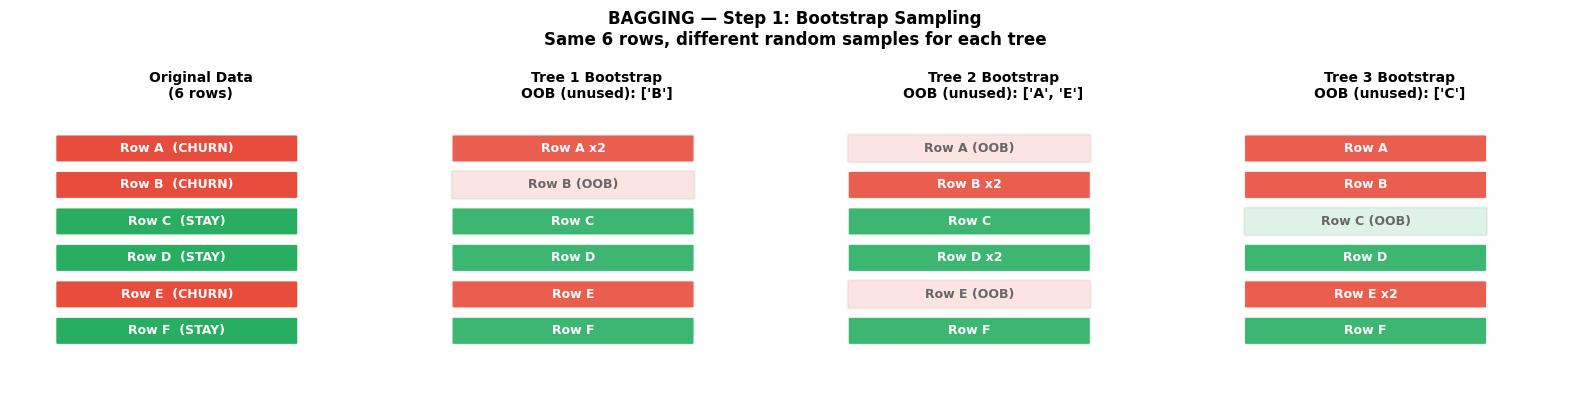

Faded rows = OOB (out-of-bag). Each tree trains on different data.
x2 means the row was sampled twice (with replacement).



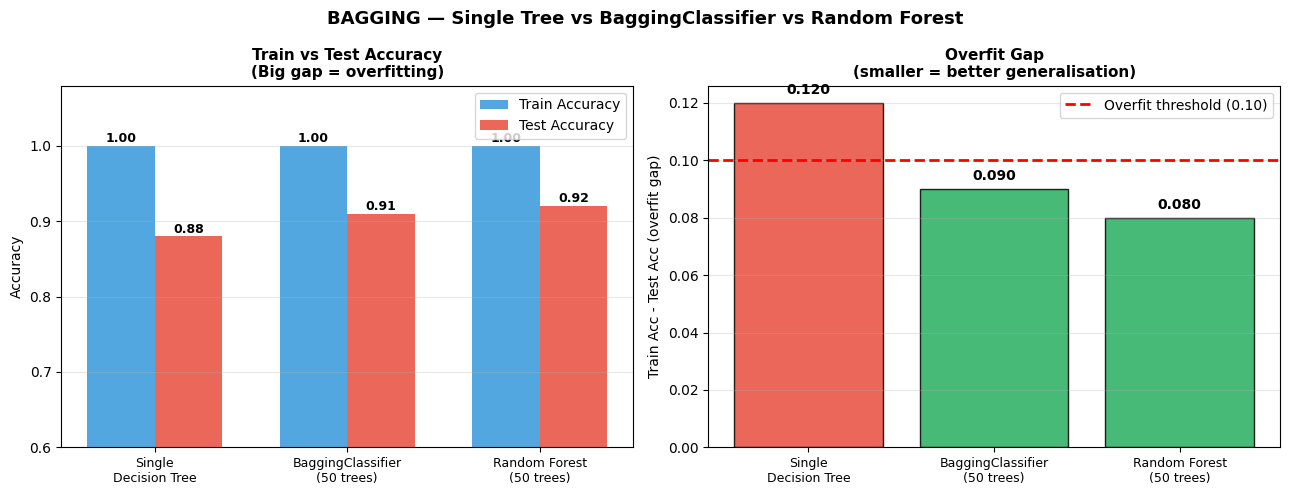

RESULTS:
Model                             Train     Test      Gap
-------------------------------------------------------
Single Decision Tree              1.000    0.880    0.120 <- OVERFIT
BaggingClassifier (50 trees)      1.000    0.910    0.090 <- OK
Random Forest (50 trees)          1.000    0.920    0.080 <- OK

Random Forest OOB Score: 0.895 (free estimate of test accuracy)

HOW TO USE BAGGING IN SKLEARN

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Option 1: Generic BaggingClassifier (works with any base model)
bag = BaggingClassifier(
    estimator    = DecisionTreeClassifier(),  # base model
    n_estimators = 100,    # number of trees
    max_samples  = 0.8,    # use 80% of data per tree
    max_features = 0.8,    # use 80% of features per tree
    bootstrap    = True,   # sample WITH replacement
    oob_score    = True,   # free OOB validation
    n_jobs       = -1,     # use all CPU cores
    ran

In [22]:
# ============================================================
# BAGGING — visual demo + sklearn usage
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

CHURN = '#e74c3c'; STAY = '#27ae60'; BLUE = '#2980b9'

# ----------------------------------------------------------
# DIAGRAM 1 — Bootstrap sampling visualised
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('BAGGING — Step 1: Bootstrap Sampling\n'
             'Same 6 rows, different random samples for each tree',
             fontsize=12, fontweight='bold')

original = ['A','B','C','D','E','F']
colors_o = [CHURN,CHURN,STAY,STAY,CHURN,STAY]
samples  = [
    ['A','A','C','D','E','F'],
    ['B','B','C','D','D','F'],
    ['A','B','D','E','E','F'],
]

# Original data
ax = axes[0]
ax.set_xlim(0,8); ax.set_ylim(0,10); ax.axis('off')
ax.set_title('Original Data\n(6 rows)', fontsize=10, fontweight='bold')
for i, (r, c) in enumerate(zip(original, colors_o)):
    yp = 8.5 - i*1.3
    ax.add_patch(mpatches.FancyBboxPatch((1,yp-0.45),5,0.9,
        boxstyle='round,pad=0.05',facecolor=c,edgecolor='white',lw=1.5))
    ax.text(3.5, yp, f'Row {r}  ({"CHURN" if c==CHURN else "STAY"})',
            ha='center',va='center',fontsize=9,color='white',fontweight='bold')

# Each tree's bootstrap sample
for ti, (ax, sample) in enumerate(zip(axes[1:], samples)):
    oob = sorted(set(original) - set(sample))
    ax.set_xlim(0,8); ax.set_ylim(0,10); ax.axis('off')
    ax.set_title(f'Tree {ti+1} Bootstrap\nOOB (unused): {oob}',
                 fontsize=10, fontweight='bold')
    from collections import Counter
    counts = Counter(sample)
    for i, r in enumerate(original):
        yp  = 8.5 - i*1.3
        c   = colors_o[original.index(r)]
        cnt = counts.get(r, 0)
        alpha = 0.9 if cnt > 0 else 0.15
        ec    = 'white' if cnt > 0 else '#aaa'
        ax.add_patch(mpatches.FancyBboxPatch((1,yp-0.45),5,0.9,
            boxstyle='round,pad=0.05',facecolor=c,
            edgecolor=ec,lw=1.5,alpha=alpha))
        lbl = f'Row {r}' + (f' x{cnt}' if cnt>1 else '') + (' (OOB)' if cnt==0 else '')
        ax.text(3.5,yp,lbl,ha='center',va='center',
                fontsize=9,color='white' if alpha>0.5 else '#666',fontweight='bold')

plt.tight_layout(); plt.show()
print('Faded rows = OOB (out-of-bag). Each tree trains on different data.')
print('x2 means the row was sampled twice (with replacement).\n')

# ----------------------------------------------------------
# DIAGRAM 2 — Single Tree vs Bagging accuracy comparison
# ----------------------------------------------------------
np.random.seed(42)
X, y = make_classification(n_samples=500, n_features=10,
                            n_informative=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

single_tree = DecisionTreeClassifier(random_state=42)
bagging     = BaggingClassifier(n_estimators=50, random_state=42)
rf          = RandomForestClassifier(n_estimators=50, random_state=42, oob_score=True)

single_tree.fit(X_train, y_train)
bagging.fit(X_train, y_train)
rf.fit(X_train, y_train)

results = {
    'Single\nDecision Tree': (
        accuracy_score(y_train, single_tree.predict(X_train)),
        accuracy_score(y_test,  single_tree.predict(X_test))),
    'BaggingClassifier\n(50 trees)': (
        accuracy_score(y_train, bagging.predict(X_train)),
        accuracy_score(y_test,  bagging.predict(X_test))),
    'Random Forest\n(50 trees)': (
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_test,  rf.predict(X_test))),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('BAGGING — Single Tree vs BaggingClassifier vs Random Forest',
             fontsize=13, fontweight='bold')

names  = list(results.keys())
trains = [v[0] for v in results.values()]
tests  = [v[1] for v in results.values()]
x = np.arange(len(names))
w = 0.35

axes[0].bar(x-w/2, trains, w, label='Train Accuracy', color='#3498db', alpha=0.85)
axes[0].bar(x+w/2, tests,  w, label='Test Accuracy',  color='#e74c3c', alpha=0.85)
for xi, (tr, te) in enumerate(zip(trains, tests)):
    axes[0].text(xi-w/2, tr+0.005, f'{tr:.2f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(xi+w/2, te+0.005, f'{te:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(names, fontsize=9)
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0.6, 1.08)
axes[0].set_title('Train vs Test Accuracy\n(Big gap = overfitting)',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3, axis='y')

gaps = [tr-te for tr,te in zip(trains,tests)]
gap_cols = ['#e74c3c' if g>0.1 else '#27ae60' for g in gaps]
axes[1].bar(names, gaps, color=gap_cols, alpha=0.85, edgecolor='black')
for xi, g in enumerate(gaps):
    axes[1].text(xi, g+0.003, f'{g:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(0.1, color='red', lw=2, linestyle='--', label='Overfit threshold (0.10)')
axes[1].set_ylabel('Train Acc - Test Acc (overfit gap)')
axes[1].set_title('Overfit Gap\n(smaller = better generalisation)',
                  fontsize=11, fontweight='bold')
axes[1].set_xticks(range(len(names))); axes[1].set_xticklabels(names, fontsize=9)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print('RESULTS:')
print(f'{"Model":<30} {"Train":>8} {"Test":>8} {"Gap":>8}')
print('-'*55)
for name,(tr,te) in results.items():
    flag = ' <- OVERFIT' if (tr-te)>0.1 else ' <- OK'
    print(f'{name.replace(chr(10)," "):<30} {tr:>8.3f} {te:>8.3f} {tr-te:>8.3f}{flag}')
print(f'\nRandom Forest OOB Score: {rf.oob_score_:.3f} (free estimate of test accuracy)')

# ----------------------------------------------------------
# HOW TO USE — sklearn quick reference
# ----------------------------------------------------------
print('\n' + '='*55)
print('HOW TO USE BAGGING IN SKLEARN')
print('='*55)
print('''
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Option 1: Generic BaggingClassifier (works with any base model)
bag = BaggingClassifier(
    estimator    = DecisionTreeClassifier(),  # base model
    n_estimators = 100,    # number of trees
    max_samples  = 0.8,    # use 80% of data per tree
    max_features = 0.8,    # use 80% of features per tree
    bootstrap    = True,   # sample WITH replacement
    oob_score    = True,   # free OOB validation
    n_jobs       = -1,     # use all CPU cores
    random_state = 42
)
bag.fit(X_train, y_train)
print(bag.oob_score_)      # free test score!

# Option 2: Random Forest (Bagging + feature randomness)
rf = RandomForestClassifier(
    n_estimators = 100,    # number of trees
    max_features = 'sqrt', # sqrt(n_features) per split
    oob_score    = True,
    n_jobs       = -1,
    random_state = 42
)
rf.fit(X_train, y_train)
predictions = rf.predict(X_test)
probabilities = rf.predict_proba(X_test)  # confidence scores
''')


---
# SECTION C — Boosting

---

## What is Boosting?

> **Definition:** Train models **sequentially** — each new model focuses on the mistakes
> the previous model made. Wrong predictions get more attention in the next round.

Key difference from Bagging:
- **Bagging** = trees are independent, train in parallel
- **Boosting** = trees are dependent, each one corrects the previous one's errors

---

## Simple Real-Life Analogy

**You are a student preparing for an exam:**

```
Round 1: Study everything equally.
         Take a practice test. Get questions 3, 7, 12 wrong.

Round 2: Focus EXTRA time on questions 3, 7, 12.
         Take another test. Now get questions 7, 15 wrong.

Round 3: Focus EXTRA time on questions 7, 15.
         Take another test. Now get only question 15 wrong.

Each round you get better because you focus on what you got WRONG.
Boosting works exactly the same way.
```

In ML: each round = one Decision Tree. Wrong predictions get higher weight.

---

## How Boosting Works — Step by Step

```
ORIGINAL DATA: 6 customers  [A, B, C, D, E, F]
All start with equal weight: 1/6 each

ROUND 1 — Train Tree 1 on original data:
  Tree 1 predicts: A=correct, B=correct, C=WRONG, D=correct, E=WRONG, F=correct
  -> Increase weight of C and E (the wrong ones)
  Weights: A=1/8, B=1/8, C=3/8, D=1/8, E=3/8, F=1/8  (C and E get more focus)

ROUND 2 — Train Tree 2, paying MORE attention to C and E:
  Tree 2 predicts: C=correct, E=correct, but now B=WRONG, D=WRONG
  -> Increase weight of B and D

ROUND 3 — Train Tree 3, paying MORE attention to B and D:
  Tree 3 corrects B and D.

FINAL PREDICTION = weighted vote of all 3 trees
  (better trees get higher weight in the final vote)
```

---

## Bagging vs Boosting — Side by Side

```
BAGGING                              BOOSTING
─────────────────────────────────    ─────────────────────────────────
Trees built in PARALLEL              Trees built SEQUENTIALLY
Each tree is INDEPENDENT             Each tree CORRECTS previous errors
All rows have EQUAL weight           Wrong rows get HIGHER weight
Final = majority vote / average      Final = WEIGHTED vote
Reduces VARIANCE (overfitting)       Reduces BIAS (underfitting)
ROBUST, hard to overfit              CAN overfit on noisy data
FAST (parallel)                      SLOWER (must go one by one)
Use when model OVERFITS              Use when model UNDERFITS
```

---

## Boosting Algorithms

| Algorithm | How it boosts | Best for |
|-----------|--------------|----------|
| **AdaBoost** | Increases weight of misclassified rows | Simple, fast, classification |
| **Gradient Boosting** | Each tree fits the residual errors (what previous got wrong) | Structured/tabular data |
| **XGBoost** | Gradient Boosting + L1/L2 regularisation + parallel split finding | Competitions, best accuracy |
| **LightGBM** | Like XGBoost but faster — grows trees leaf-wise | Very large datasets |
| **CatBoost** | Handles categorical features natively | Datasets with many categories |

---

## Advantages of Boosting

| # | Advantage | Why |
|---|-----------|-----|
| 1 | **Highest accuracy** | State-of-the-art on tabular data | 
| 2 | **Reduces bias** | Keeps correcting mistakes round after round |
| 3 | **Feature importance** | Tells you which features mattered most |
| 4 | **Handles imbalanced data** | Can assign higher weight to minority class |
| 5 | **Flexible loss functions** | Works for classification, regression, ranking |

## Disadvantages of Boosting

| # | Disadvantage | Impact |
|---|-------------|--------|
| 1 | **Can overfit on noisy data** | Wrong rows get boosted and dominate |
| 2 | **Sequential — slow to train** | Cannot parallelise across trees |
| 3 | **Many hyperparameters** | learning_rate, n_estimators, max_depth all matter |
| 4 | **Black box** | Even harder to explain than Bagging |
| 5 | **Sensitive to outliers** | Outliers get boosted and distort the model |

---

## When to use Boosting?

```
USE Boosting when:
  - You need the highest possible accuracy
  - Your model underfits (high bias — too simple)
  - You have clean, structured/tabular data
  - You are entering a Kaggle competition

DO NOT USE when:
  - Your data is very noisy (outliers will get boosted)
  - Training time is critical
  - You need simple, explainable predictions
  - Dataset is very small (risk of overfitting)
```

---

**Run the code cell below** — it draws how boosting corrects errors round by round,
then compares AdaBoost vs GradientBoosting vs RandomForest.


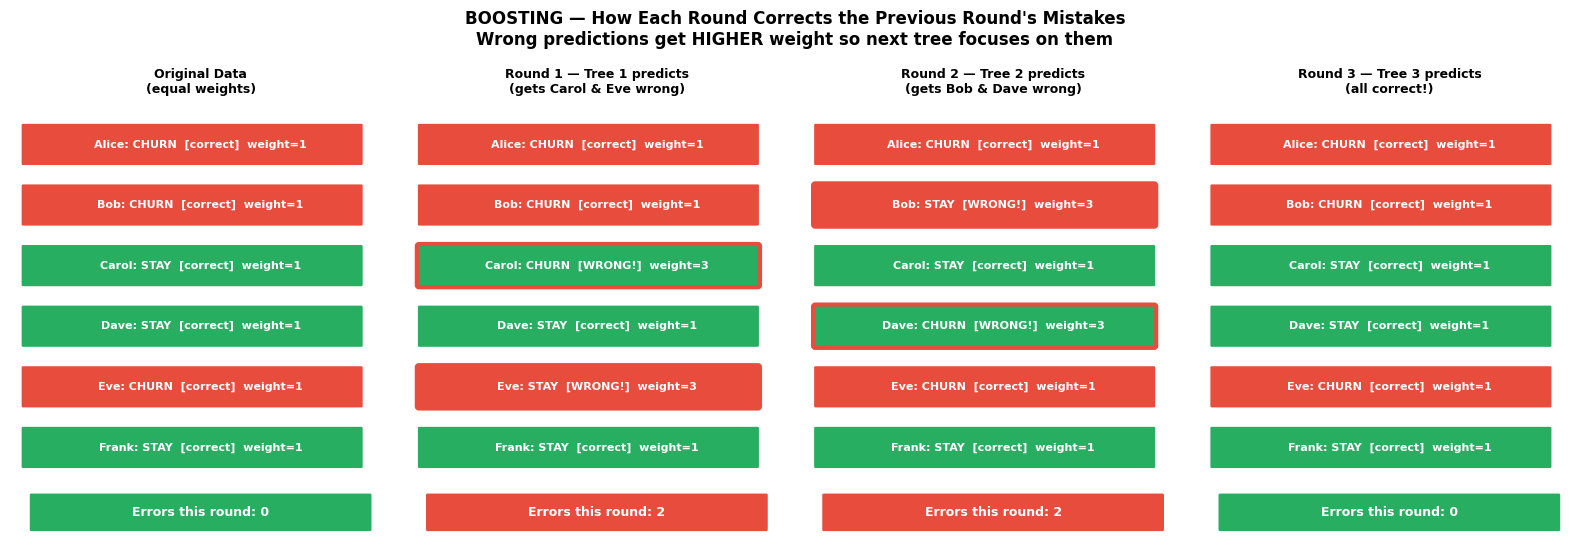

Red border = wrong prediction. Higher weight = more focus in next round.
Each round the model gets better by correcting previous mistakes.



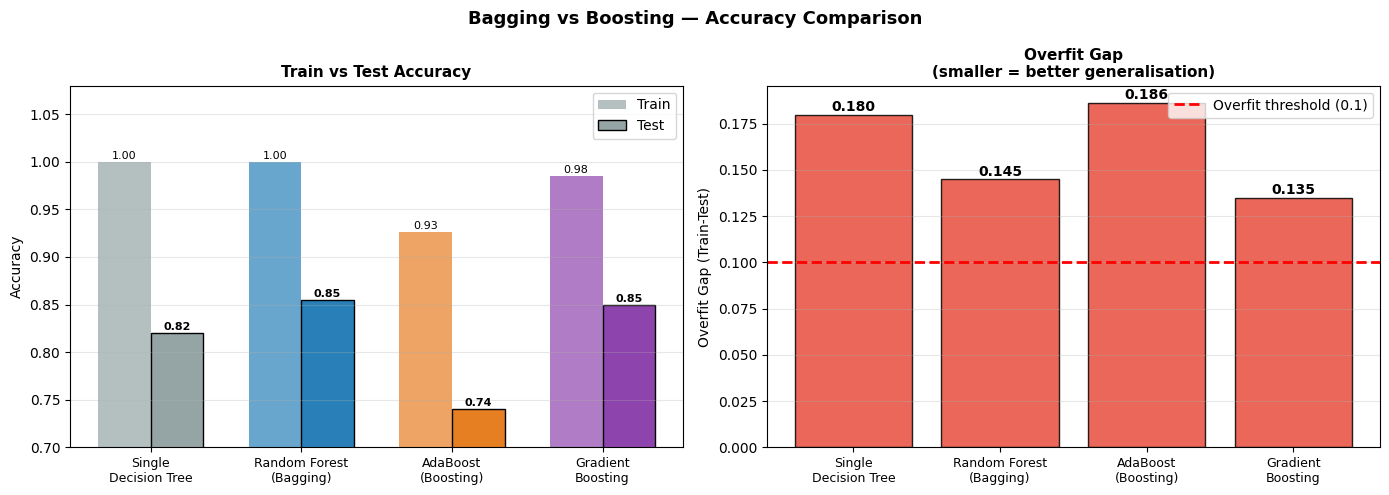

Model                             Train     Test      Gap  Note
----------------------------------------------------------------------
Single Decision Tree              1.000    0.820    0.180  Overfit!
Random Forest (Bagging)           1.000    0.855    0.145  Stable
AdaBoost (Boosting)               0.926    0.740    0.186  Good
Gradient Boosting                 0.985    0.850    0.135  Best acc

HOW TO USE BOOSTING IN SKLEARN

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# Option 1: AdaBoost
#   - adjusts sample weights each round
#   - fast, good baseline boosting model
ada = AdaBoostClassifier(
    n_estimators  = 100,   # number of rounds
    learning_rate = 0.1,   # shrinks each tree contribution
    random_state  = 42
)
ada.fit(X_train, y_train)
ada.predict(X_test)

# Option 2: Gradient Boosting
#   - each tree fits the RESIDUAL (remaining error)
#   - more flexible, usually higher accuracy
gb = GradientBoostingClassifier(
    n_estimators  = 100

In [23]:
# ============================================================
# BOOSTING — visual demo + sklearn usage
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (AdaBoostClassifier,
                               GradientBoostingClassifier,
                               RandomForestClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

CHURN='#e74c3c'; STAY='#27ae60'; BLUE='#2980b9'; ORANGE='#e67e22'

# ----------------------------------------------------------
# DIAGRAM 1 — How boosting corrects errors round by round
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 5.5))
fig.suptitle('BOOSTING — How Each Round Corrects the Previous Round\'s Mistakes\n'
             'Wrong predictions get HIGHER weight so next tree focuses on them',
             fontsize=12, fontweight='bold')

customers = ['Alice','Bob','Carol','Dave','Eve','Frank']
true_label = ['CHURN','CHURN','STAY','STAY','CHURN','STAY']
true_col   = [CHURN,CHURN,STAY,STAY,CHURN,STAY]

# Round 1 predictions (tree 1 gets C and E wrong)
r1_pred  = ['CHURN','CHURN','CHURN','STAY','STAY','STAY']
r1_wrong = [p!=t for p,t in zip(r1_pred, true_label)]
# Round 2: higher weight on C and E, now gets B and D wrong
r2_pred  = ['CHURN','STAY','STAY','CHURN','CHURN','STAY']
r2_wrong = [p!=t for p,t in zip(r2_pred, true_label)]
# Round 3: fixes B and D
r3_pred  = ['CHURN','CHURN','STAY','STAY','CHURN','STAY']
r3_wrong = [p!=t for p,t in zip(r3_pred, true_label)]

rounds = [
    ('Original Data\n(equal weights)', true_label, [False]*6, [1]*6),
    ('Round 1 — Tree 1 predicts\n(gets Carol & Eve wrong)', r1_pred, r1_wrong, [1,1,3,1,3,1]),
    ('Round 2 — Tree 2 predicts\n(gets Bob & Dave wrong)',  r2_pred, r2_wrong, [1,3,1,3,1,1]),
    ('Round 3 — Tree 3 predicts\n(all correct!)',           r3_pred, r3_wrong, [1,1,1,1,1,1]),
]

for ax, (title, preds, wrongs, weights) in zip(axes, rounds):
    ax.set_xlim(0,9); ax.set_ylim(0,10); ax.axis('off')
    ax.set_title(title, fontsize=9, fontweight='bold')
    for i, (name, pred, wrong, w) in enumerate(zip(customers,preds,wrongs,weights)):
        yp  = 9.0 - i*1.4
        col = true_col[i]
        bw  = 0.8 + w*0.12
        # row box
        ax.add_patch(mpatches.FancyBboxPatch((0.3,yp-0.45),8.0,0.9,
            boxstyle='round,pad=0.05',facecolor=col,
            edgecolor='#e74c3c' if wrong else 'white',
            lw=3 if wrong else 1.5))
        status = 'WRONG!' if wrong else 'correct'
        ax.text(4.5,yp,f'{name}: {pred}  [{status}]  weight={w}',
                ha='center',va='center',fontsize=8,
                color='white',fontweight='bold')
    wrong_count = sum(wrongs)
    col_s = '#e74c3c' if wrong_count>0 else '#27ae60'
    ax.add_patch(mpatches.FancyBboxPatch((0.5,0.1),8,0.8,
        boxstyle='round,pad=0.05',facecolor=col_s,edgecolor='white',lw=1))
    ax.text(4.5,0.5,f'Errors this round: {wrong_count}',
            ha='center',va='center',fontsize=9,color='white',fontweight='bold')

plt.tight_layout(); plt.show()
print('Red border = wrong prediction. Higher weight = more focus in next round.')
print('Each round the model gets better by correcting previous mistakes.\n')

# ----------------------------------------------------------
# DIAGRAM 2 — Compare all ensemble methods
# ----------------------------------------------------------
np.random.seed(42)
X, y = make_classification(n_samples=1000, n_features=10,
                            n_informative=6, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

models = {
    'Single\nDecision Tree':      DecisionTreeClassifier(random_state=42),
    'Random Forest\n(Bagging)':   RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost\n(Boosting)':       AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient\nBoosting':         GradientBoostingClassifier(n_estimators=100,
                                       learning_rate=0.1, random_state=42),
}

train_accs, test_accs = [], []
for name, m in models.items():
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  m.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bagging vs Boosting — Accuracy Comparison', fontsize=13, fontweight='bold')

names = list(models.keys())
x = np.arange(len(names)); w = 0.35
bar_cols = ['#95a5a6', BLUE, ORANGE, '#8e44ad']

axes[0].bar(x-w/2, train_accs, w, label='Train', color=bar_cols, alpha=0.7)
axes[0].bar(x+w/2, test_accs,  w, label='Test',  color=bar_cols, alpha=1.0, edgecolor='black')
for xi,(tr,te) in enumerate(zip(train_accs,test_accs)):
    axes[0].text(xi-w/2, tr+0.003, f'{tr:.2f}', ha='center', fontsize=8)
    axes[0].text(xi+w/2, te+0.003, f'{te:.2f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(names, fontsize=9)
axes[0].set_ylim(0.7,1.08); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True,alpha=0.3,axis='y')

gaps = [tr-te for tr,te in zip(train_accs,test_accs)]
gcols = ['#e74c3c' if g>0.1 else '#27ae60' for g in gaps]
axes[1].bar(names, gaps, color=gcols, alpha=0.85, edgecolor='black')
for xi,g in enumerate(gaps):
    axes[1].text(xi, g+0.002, f'{g:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(0.1,color='red',lw=2,linestyle='--',label='Overfit threshold (0.1)')
axes[1].set_xticks(range(len(names))); axes[1].set_xticklabels(names, fontsize=9)
axes[1].set_ylabel('Overfit Gap (Train-Test)')
axes[1].set_title('Overfit Gap\n(smaller = better generalisation)',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True,alpha=0.3,axis='y')

plt.tight_layout(); plt.show()

print(f'{"Model":<30} {"Train":>8} {"Test":>8} {"Gap":>8}  Note')
print('-'*70)
notes = ['Overfit!','Stable','Good','Best acc']
for (name,_),(tr,te),note in zip(models.items(),zip(train_accs,test_accs),notes):
    print(f'{name.replace(chr(10)," "):<30} {tr:>8.3f} {te:>8.3f} {tr-te:>8.3f}  {note}')

# ----------------------------------------------------------
# HOW TO USE — sklearn quick reference
# ----------------------------------------------------------
print('\n' + '='*55)
print('HOW TO USE BOOSTING IN SKLEARN')
print('='*55)
print('''
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# Option 1: AdaBoost
#   - adjusts sample weights each round
#   - fast, good baseline boosting model
ada = AdaBoostClassifier(
    n_estimators  = 100,   # number of rounds
    learning_rate = 0.1,   # shrinks each tree contribution
    random_state  = 42
)
ada.fit(X_train, y_train)
ada.predict(X_test)

# Option 2: Gradient Boosting
#   - each tree fits the RESIDUAL (remaining error)
#   - more flexible, usually higher accuracy
gb = GradientBoostingClassifier(
    n_estimators  = 100,   # number of trees
    learning_rate = 0.1,   # small = more trees needed but better
    max_depth     = 3,     # keep trees shallow to avoid overfit
    random_state  = 42
)
gb.fit(X_train, y_train)
gb.predict_proba(X_test)

# Option 3: XGBoost (install with: pip install xgboost)
#   - fastest, regularised, best for competitions
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators  = 100,
    learning_rate = 0.1,
    max_depth     = 4,
    reg_lambda    = 1.0,   # L2 regularisation
    random_state  = 42
)
xgb.fit(X_train, y_train, eval_set=[(X_test,y_test)], verbose=False)
xgb.predict(X_test)
''')


In [6]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [7]:
# Step 2: Create a Realistic Customer Churn Dataset
np.random.seed(42)

n_churn    = 150
n_no_churn = 300

# Customers who CHURN: short tenure, high charges, month-to-month contract
churn_data = {
    'tenure_months':     np.random.randint(1, 18, n_churn),
    'monthly_charges':   np.random.uniform(70, 120, n_churn),
    'num_products':      np.random.randint(1, 3, n_churn),
    'has_tech_support':  np.random.choice([0, 1], n_churn, p=[0.75, 0.25]),
    'contract_type':     np.random.choice([0, 1, 2], n_churn, p=[0.70, 0.20, 0.10]),
    'payment_method':    np.random.choice([0, 1, 2, 3], n_churn),
    'num_support_calls': np.random.randint(3, 10, n_churn),
    'label': [1] * n_churn
}

# Customers who STAY: long tenure, lower charges, annual/two-year contract
stay_data = {
    'tenure_months':     np.random.randint(12, 72, n_no_churn),
    'monthly_charges':   np.random.uniform(40, 85, n_no_churn),
    'num_products':      np.random.randint(2, 5, n_no_churn),
    'has_tech_support':  np.random.choice([0, 1], n_no_churn, p=[0.30, 0.70]),
    'contract_type':     np.random.choice([0, 1, 2], n_no_churn, p=[0.20, 0.40, 0.40]),
    'payment_method':    np.random.choice([0, 1, 2, 3], n_no_churn),
    'num_support_calls': np.random.randint(0, 4, n_no_churn),
    'label': [0] * n_no_churn
}

df = pd.concat([
    pd.DataFrame(churn_data),
    pd.DataFrame(stay_data)
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

# contract_type: 0=Month-to-Month, 1=One-Year, 2=Two-Year
# payment_method: 0=Electronic check, 1=Mailed check, 2=Bank transfer, 3=Credit card

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:')
print(df['label'].value_counts().rename({0: 'Stayed', 1: 'Churned'}))
df.head(10)

Dataset shape: (450, 8)

Class distribution:
Stayed     300
Churned    150
Name: label, dtype: int64


,tenure_months,monthly_charges,num_products,has_tech_support,contract_type,payment_method,num_support_calls,label
0,22,63.865948,2,1,0,0,1,0
1,20,49.465731,4,1,2,1,3,0
2,7,87.932339,2,1,0,1,4,1
3,9,74.808828,1,0,1,1,7,1
4,46,40.055433,3,1,1,2,1,0
5,70,44.639219,4,1,2,1,0,0
6,41,76.897611,2,1,2,3,3,0
7,12,82.355688,2,1,1,3,3,0
8,43,63.626418,2,1,1,1,3,0
9,12,44.926099,3,1,0,3,0,0


In [8]:
# Step 3: Bagging Demo — Show Bootstrap Sampling in Action
print('=' * 60)
print('BOOTSTRAP SAMPLING DEMO (Bagging in Action)')
print('=' * 60)

np.random.seed(0)
original_indices = np.arange(10)
print(f'\nOriginal dataset indices: {original_indices.tolist()}')
print()

for i in range(1, 4):
    bootstrap = np.random.choice(original_indices, size=10, replace=True)
    oob = sorted(set(original_indices) - set(bootstrap))
    print(f'Tree {i} bootstrap sample : {sorted(bootstrap.tolist())} (with duplicates)')
    print(f'Tree {i} OOB (never seen)  : {oob}')
    print()

print('Key insight:')
print('  → Each tree trains on ~63% unique samples')
print('  → ~37% are OOB — used as free validation')
print('  → Each tree is different → diverse errors → better ensemble')

BOOTSTRAP SAMPLING DEMO (Bagging in Action)

Original dataset indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Tree 1 bootstrap sample : [0, 2, 3, 3, 3, 4, 5, 5, 7, 9] (with duplicates)
Tree 1 OOB (never seen)  : [1, 6, 8]

Tree 2 bootstrap sample : [1, 1, 6, 6, 7, 7, 7, 8, 8, 8] (with duplicates)
Tree 2 OOB (never seen)  : [0, 2, 3, 4, 5, 9]

Tree 3 bootstrap sample : [0, 0, 3, 3, 4, 5, 5, 8, 9, 9] (with duplicates)
Tree 3 OOB (never seen)  : [1, 2, 6, 7]

Key insight:
  → Each tree trains on ~63% unique samples
  → ~37% are OOB — used as free validation
  → Each tree is different → diverse errors → better ensemble


In [9]:
# Step 4: Feature Randomness Demo
features = ['tenure_months', 'monthly_charges', 'num_products',
            'has_tech_support', 'contract_type', 'payment_method', 'num_support_calls']

n_features = len(features)
max_features_per_split = int(np.sqrt(n_features))

print('=' * 60)
print('FEATURE RANDOMNESS DEMO')
print('=' * 60)
print(f'\nTotal features     : {n_features}')
print(f'Features per split : sqrt({n_features}) = {max_features_per_split}')
print()

np.random.seed(42)
for split_num in range(1, 6):
    chosen = np.random.choice(features, size=max_features_per_split, replace=False)
    print(f'Split {split_num} considers : {list(chosen)}')

print('\n→ Each split only sees a random subset of features')
print('→ Forces trees to find diverse patterns → reduces correlation between trees')

FEATURE RANDOMNESS DEMO

Total features     : 7
Features per split : sqrt(7) = 2

Split 1 considers : ['tenure_months', 'monthly_charges']
Split 2 considers : ['payment_method', 'tenure_months']
Split 3 considers : ['tenure_months', 'monthly_charges']
Split 4 considers : ['tenure_months', 'num_products']
Split 5 considers : ['payment_method', 'num_products']

→ Each split only sees a random subset of features
→ Forces trees to find diverse patterns → reduces correlation between trees


In [10]:
# Step 5: Train Models — Single Tree vs Random Forest (Overfitting Demo)
X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt_overfit = DecisionTreeClassifier(random_state=42)
dt_overfit.fit(X_train, y_train)

dt_pruned = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)
dt_pruned.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
rf.fit(X_train, y_train)

print('=' * 60)
print('OVERFITTING COMPARISON')
print('=' * 60)
print(f'\n{"Model":<30} {"Train Acc":>10} {"Test Acc":>10}')
print('-' * 55)

for name, model in [
    ('Decision Tree (no limit)', dt_overfit),
    ('Decision Tree (pruned)',   dt_pruned),
    ('Random Forest (100 trees)', rf),
]:
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    flag = ' <- OVERFIT' if (tr - te) > 0.1 else ''
    print(f'{name:<30} {tr:>10.1%} {te:>10.1%}{flag}')

print(f'\nRandom Forest OOB Score: {rf.oob_score_:.4f}')
print('(OOB score is a free estimate of test accuracy — no separate validation set needed!)')

OVERFITTING COMPARISON

Model                           Train Acc   Test Acc
-------------------------------------------------------
Decision Tree (no limit)           100.0%      98.9%
Decision Tree (pruned)              99.4%      97.8%
Random Forest (100 trees)          100.0%     100.0%

Random Forest OOB Score: 0.9917
(OOB score is a free estimate of test accuracy — no separate validation set needed!)


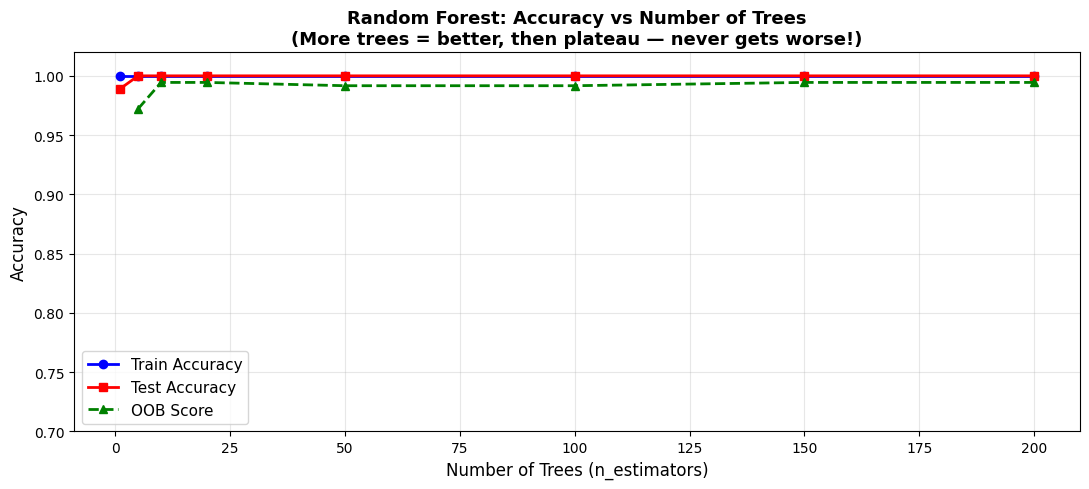

Key insight: Unlike Decision Tree depth, adding more trees NEVER causes overfitting.
After ~100 trees, accuracy plateaus — beyond that, more trees just cost compute time.


In [11]:
# Step 6: Effect of n_estimators — More Trees = Better (until plateau)
n_trees_range = [1, 5, 10, 20, 50, 100, 150, 200]
train_accs, test_accs, oob_scores = [], [], []

for n in n_trees_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42, oob_score=(n > 1))
    model.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, model.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  model.predict(X_test)))
    oob_scores.append(model.oob_score_ if n > 1 else None)

plt.figure(figsize=(11, 5))
plt.plot(n_trees_range, train_accs, 'b-o', label='Train Accuracy', linewidth=2)
plt.plot(n_trees_range, test_accs,  'r-s', label='Test Accuracy',  linewidth=2)
plt.plot(n_trees_range[1:], [s for s in oob_scores if s],
         'g--^', label='OOB Score', linewidth=2)
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Random Forest: Accuracy vs Number of Trees\n(More trees = better, then plateau — never gets worse!)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0.7, 1.02)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Key insight: Unlike Decision Tree depth, adding more trees NEVER causes overfitting.')
print('After ~100 trees, accuracy plateaus — beyond that, more trees just cost compute time.')

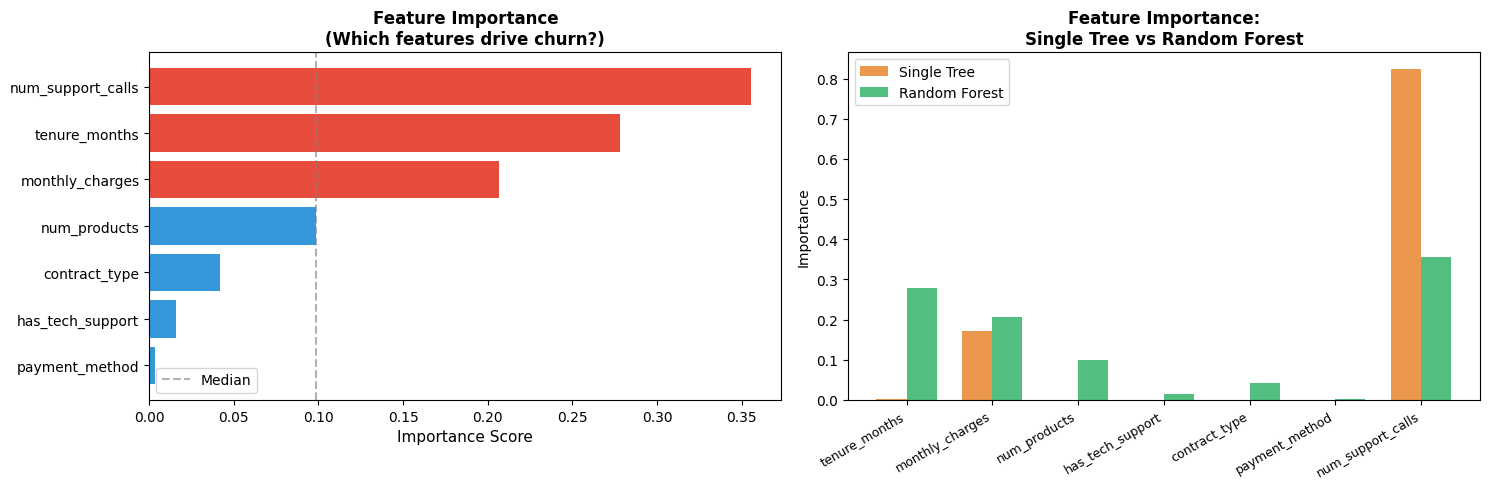

Top 3 churn drivers (Random Forest):
  num_support_calls   : 0.3558  XXXXXXXXXXXXXXXXXXXXX
  tenure_months       : 0.2784  XXXXXXXXXXXXXXXX
  monthly_charges     : 0.2068  XXXXXXXXXXXX


In [12]:
# Step 7: Feature Importance — Which Factors Drive Churn?
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#e74c3c' if i > importance_df['Importance'].median()
          else '#3498db' for i in importance_df['Importance']]
axes[0].barh(importance_df['Feature'], importance_df['Importance'], color=colors)
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Feature Importance\n(Which features drive churn?)',
                  fontsize=12, fontweight='bold')
axes[0].axvline(importance_df['Importance'].median(),
               color='gray', linestyle='--', alpha=0.6, label='Median')
axes[0].legend()

imp_rf = dict(zip(features, rf.feature_importances_))
imp_dt = dict(zip(features, dt_pruned.feature_importances_))

x = np.arange(len(features))
w = 0.35
axes[1].bar(x - w/2, [imp_dt[f] for f in features], w, label='Single Tree', color='#e67e22', alpha=0.8)
axes[1].bar(x + w/2, [imp_rf[f] for f in features], w, label='Random Forest', color='#27ae60', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(features, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Importance')
axes[1].set_title('Feature Importance:\nSingle Tree vs Random Forest',
                  fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Top 3 churn drivers (Random Forest):')
for _, row in importance_df.tail(3).iloc[::-1].iterrows():
    bar = 'X' * int(row['Importance'] * 60)
    print(f'  {row["Feature"]:<20}: {row["Importance"]:.4f}  {bar}')

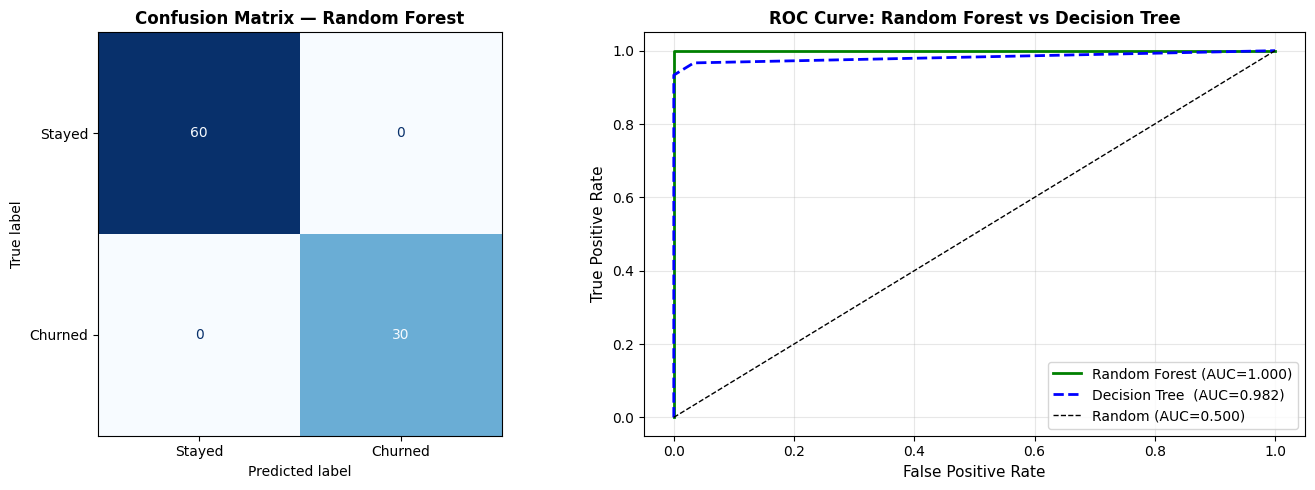

CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

      Stayed       1.00      1.00      1.00        60
     Churned       1.00      1.00      1.00        30

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

CONFUSION MATRIX BREAKDOWN:
  True Negative  (Stayed  -> Stayed)  : 60  OK
  False Positive (Stayed  -> Churned) : 0  <- Unnecessary retention effort
  False Negative (Churned -> Stayed)  : 0  <- Customer lost (missed!)
  True Positive  (Churned -> Churned) : 30  OK


In [13]:
# Step 8: Confusion Matrix & ROC Curve
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Random Forest', fontsize=12, fontweight='bold')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_pruned.predict_proba(X_test)[:, 1])
auc_rf = roc_auc_score(y_test, y_prob)
auc_dt = roc_auc_score(y_test, dt_pruned.predict_proba(X_test)[:, 1])

axes[1].plot(fpr_rf, tpr_rf, 'g-', linewidth=2, label=f'Random Forest (AUC={auc_rf:.3f})')
axes[1].plot(fpr_dt, tpr_dt, 'b--', linewidth=2, label=f'Decision Tree  (AUC={auc_dt:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve: Random Forest vs Decision Tree', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('CLASSIFICATION REPORT — Random Forest')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

print('CONFUSION MATRIX BREAKDOWN:')
print(f'  True Negative  (Stayed  -> Stayed)  : {cm[0,0]}  OK')
print(f'  False Positive (Stayed  -> Churned) : {cm[0,1]}  <- Unnecessary retention effort')
print(f'  False Negative (Churned -> Stayed)  : {cm[1,0]}  <- Customer lost (missed!)')
print(f'  True Positive  (Churned -> Churned) : {cm[1,1]}  OK')

In [14]:
# Step 9: Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [None, 5, 10],
    'max_features':     ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, oob_score=True),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print('GridSearchCV Results')
print('=' * 50)
print(f'Best Parameters  : {grid_search.best_params_}')
print(f'Best CV ROC-AUC  : {grid_search.best_score_:.4f}')
print(f'Test ROC-AUC     : {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]):.4f}')
print(f'Test Accuracy    : {best_rf.score(X_test, y_test):.4f}')
print(f'OOB Score        : {best_rf.oob_score_:.4f}')

GridSearchCV Results
Best Parameters  : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 50}
Best CV ROC-AUC  : 1.0000
Test ROC-AUC     : 1.0000
Test Accuracy    : 1.0000
OOB Score        : 0.9917


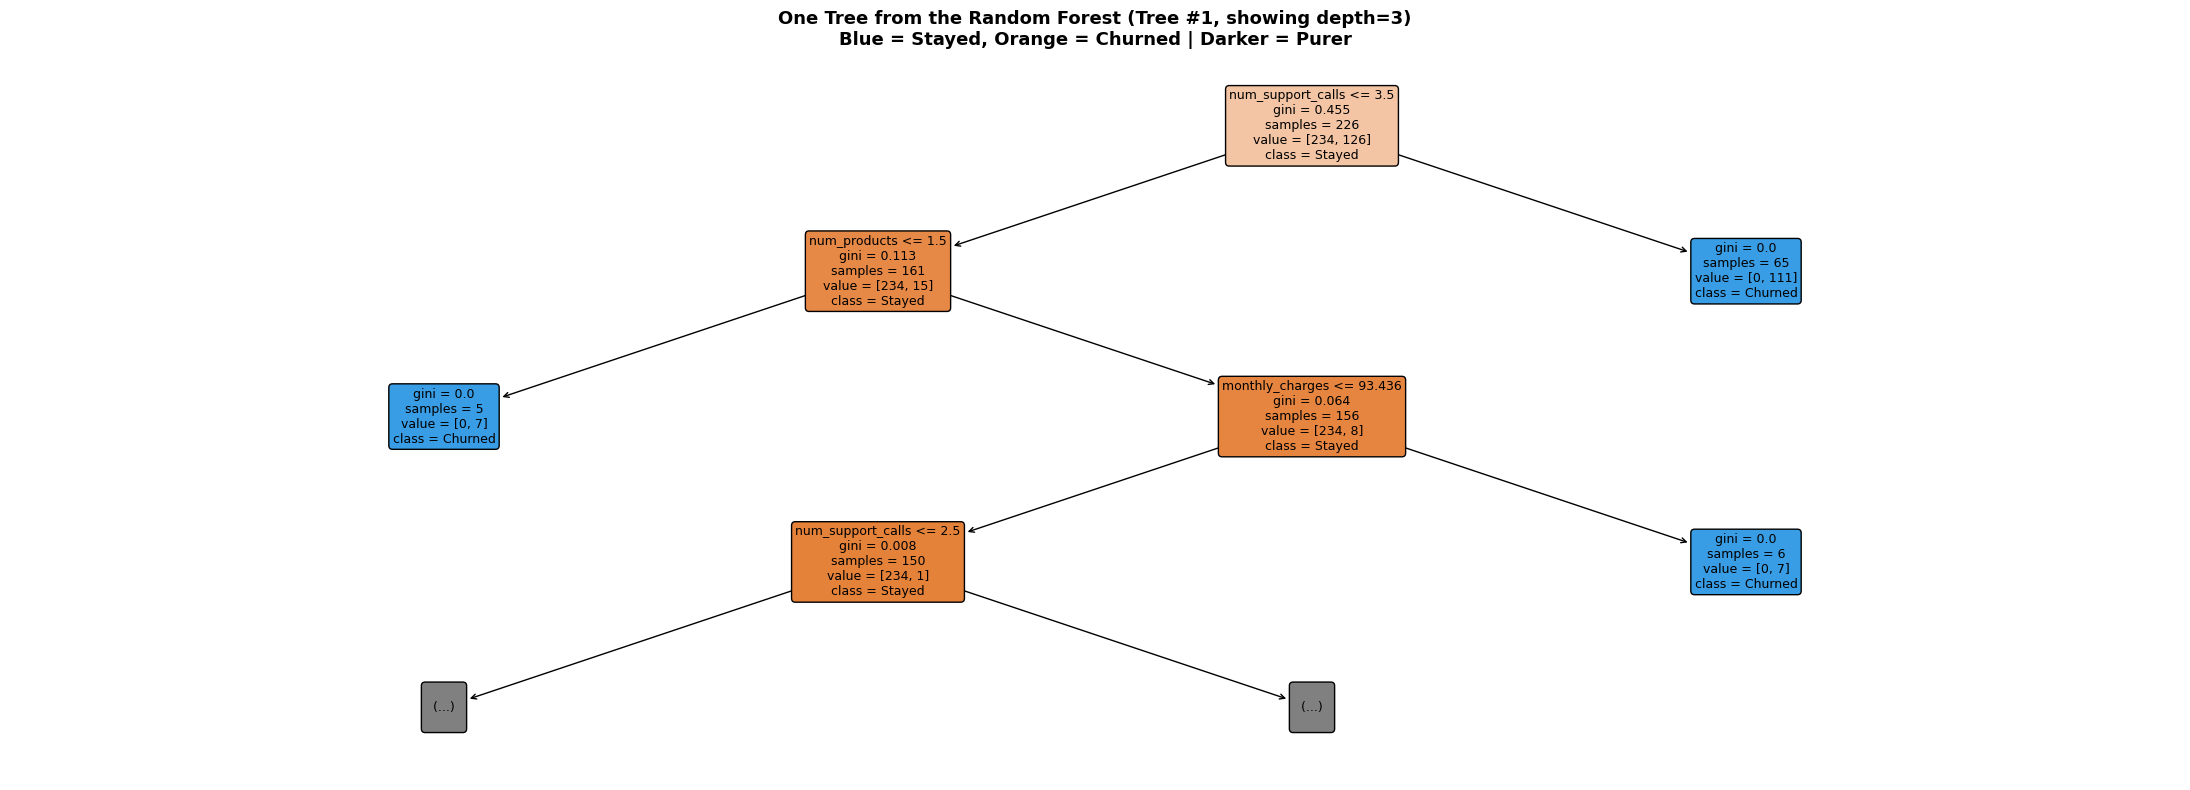

Full depth of this tree : 6
Number of leaves        : 7
Total trees in forest   : 100
Note: Each tree looks different — that is the diversity that makes Random Forest work!


In [15]:
# Step 10: Visualize One Tree from the Forest
single_tree = rf.estimators_[0]

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    single_tree,
    feature_names=features,
    class_names=['Stayed', 'Churned'],
    filled=True, rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax
)
ax.set_title(
    'One Tree from the Random Forest (Tree #1, showing depth=3)\n'
    'Blue = Stayed, Orange = Churned | Darker = Purer',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f'Full depth of this tree : {single_tree.get_depth()}')
print(f'Number of leaves        : {single_tree.get_n_leaves()}')
print(f'Total trees in forest   : {len(rf.estimators_)}')
print('Note: Each tree looks different — that is the diversity that makes Random Forest work!')

In [16]:
# Step 11: OOB Score vs Cross-Validation Comparison
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')

print('OOB Score vs Cross-Validation')
print('=' * 45)
print(f'OOB Score        : {rf.oob_score_:.4f}  <- free, no extra computation')
print(f'5-Fold CV Mean   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'5-Fold CV Scores : {[round(s, 4) for s in cv_scores]}')
print()
print('Both estimates agree closely — OOB is a reliable free alternative to CV!')
print('OOB advantage: No need to re-train the model — computed during training.')

OOB Score vs Cross-Validation
OOB Score        : 0.9917  <- free, no extra computation
5-Fold CV Mean   : 0.9944 +/- 0.0068
5-Fold CV Scores : [0.9861, 1.0, 1.0, 0.9861, 1.0]

Both estimates agree closely — OOB is a reliable free alternative to CV!
OOB advantage: No need to re-train the model — computed during training.


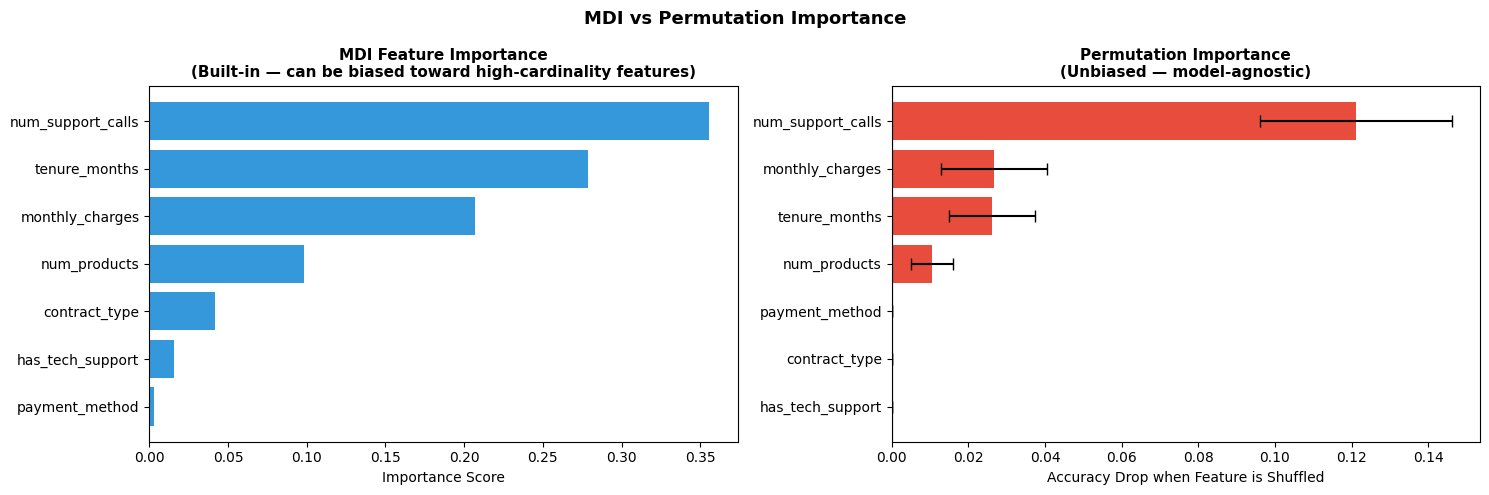

Permutation Importance Ranking:
          Feature  MDI Importance  Perm Importance
num_support_calls        0.355759         0.121111
  monthly_charges        0.206821         0.026667
    tenure_months        0.278412         0.026111
     num_products        0.098436         0.010556
 has_tech_support        0.015606         0.000000
    contract_type        0.041715         0.000000
   payment_method        0.003250         0.000000


In [17]:
# Step 12: Permutation Importance vs MDI
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature':         features,
    'MDI Importance':  rf.feature_importances_,
    'Perm Importance': perm_result.importances_mean,
    'Perm Std':        perm_result.importances_std,
}).sort_values('Perm Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mdi_sorted = perm_df.sort_values('MDI Importance')
axes[0].barh(mdi_sorted['Feature'], mdi_sorted['MDI Importance'], color='#3498db')
axes[0].set_title('MDI Feature Importance\n(Built-in — can be biased toward high-cardinality features)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importance Score')

perm_sorted = perm_df.sort_values('Perm Importance')
axes[1].barh(perm_sorted['Feature'], perm_sorted['Perm Importance'],
             xerr=perm_sorted['Perm Std'], color='#e74c3c', capsize=4)
axes[1].set_title('Permutation Importance\n(Unbiased — model-agnostic)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Accuracy Drop when Feature is Shuffled')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('MDI vs Permutation Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Permutation Importance Ranking:')
print(perm_df[['Feature', 'MDI Importance', 'Perm Importance']].to_string(index=False))

In [18]:
# Step 13: Class Imbalance Handling with class_weight='balanced'
# Create imbalanced dataset (90% Stayed, 10% Churned)
stay_idx  = df[df['label'] == 0].index
churn_idx = df[df['label'] == 1].index[:30]
df_imb    = df.loc[stay_idx.tolist() + churn_idx.tolist()].reset_index(drop=True)

X_i = df_imb[features]
y_i = df_imb['label']
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_i, y_i, test_size=0.2, random_state=42, stratify=y_i
)

print('Imbalanced dataset training distribution:')
print(y_tr_i.value_counts().rename({0: 'Stayed', 1: 'Churned'}))
print()

rf_default  = RandomForestClassifier(n_estimators=100, random_state=42)
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

rf_default.fit(X_tr_i, y_tr_i)
rf_balanced.fit(X_tr_i, y_tr_i)

print(f'{"Model":<35} {"Accuracy":>10} {"ROC-AUC":>10}')
print('-' * 60)
for name, model in [('RF Default', rf_default), ('RF Balanced Weights', rf_balanced)]:
    acc = model.score(X_te_i, y_te_i)
    auc = roc_auc_score(y_te_i, model.predict_proba(X_te_i)[:, 1])
    print(f'{name:<35} {acc:>10.4f} {auc:>10.4f}')

print('\nNote: High accuracy can be misleading on imbalanced data.')
print('ROC-AUC is the better metric — balanced weights improve minority class recall.')

Imbalanced dataset training distribution:
Stayed     240
Churned     24
Name: label, dtype: int64

Model                                 Accuracy    ROC-AUC
------------------------------------------------------------
RF Default                              1.0000     1.0000
RF Balanced Weights                     1.0000     1.0000

Note: High accuracy can be misleading on imbalanced data.
ROC-AUC is the better metric — balanced weights improve minority class recall.


In [19]:
# Step 14: Predict New Customers — Practical Demo
new_customers = pd.DataFrame({
    'tenure_months':     [2,  48,  6,  60],
    'monthly_charges':   [95, 55, 110, 45],
    'num_products':      [1,   4,   1,  3],
    'has_tech_support':  [0,   1,   0,  1],
    'contract_type':     [0,   2,   0,  1],
    'payment_method':    [0,   2,   0,  3],
    'num_support_calls': [7,   1,   8,  0],
})

descriptions = [
    'New customer, high charges, month-to-month, many complaints',
    'Long-term customer, low charges, 2-year contract, tech support',
    'Short tenure, very high charges, no support, many calls',
    'Long tenure, low charges, 1-year contract, no complaints',
]

predictions  = rf.predict(new_customers)
probabilities = rf.predict_proba(new_customers)

print('=' * 68)
print('LIVE CHURN PREDICTION DEMO')
print('=' * 68)

for desc, pred, prob in zip(descriptions, predictions, probabilities):
    label = 'CHURN' if pred == 1 else 'STAY'
    risk  = 'HIGH' if prob[1] > 0.7 else 'MEDIUM' if prob[1] > 0.4 else 'LOW'
    print(f'\nCustomer: "{desc}"')
    print(f'  Prediction  : {label}')
    print(f'  Confidence  : Stay={prob[0]:.0%}, Churn={prob[1]:.0%}')
    print(f'  Risk Level  : {risk}')

LIVE CHURN PREDICTION DEMO

Customer: "New customer, high charges, month-to-month, many complaints"
  Prediction  : CHURN
  Confidence  : Stay=0%, Churn=100%
  Risk Level  : HIGH

Customer: "Long-term customer, low charges, 2-year contract, tech support"
  Prediction  : STAY
  Confidence  : Stay=100%, Churn=0%
  Risk Level  : LOW

Customer: "Short tenure, very high charges, no support, many calls"
  Prediction  : CHURN
  Confidence  : Stay=0%, Churn=100%
  Risk Level  : HIGH

Customer: "Long tenure, low charges, 1-year contract, no complaints"
  Prediction  : STAY
  Confidence  : Stay=100%, Churn=0%
  Risk Level  : LOW


---
# PART 2: Advanced Topics & GFG Reference Code
---

In [20]:
# Step 15: Bagging vs Boosting — Side-by-Side Demo (GFG)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression

X = df[features]
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    # Bagging family
    'Bagging (BaggingClassifier)': BaggingClassifier(n_estimators=100, random_state=42),
    'Random Forest (Bagging++)':   RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True),
    # Boosting family
    'AdaBoost (Boosting)':         AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':           GradientBoostingClassifier(n_estimators=100, random_state=42),
    # Stacking
    'Stacking (RF + GBM + LR)': StackingClassifier(
        estimators=[
            ('rf',  RandomForestClassifier(n_estimators=50, random_state=42)),
            ('gbm', GradientBoostingClassifier(n_estimators=50, random_state=42)),
        ],
        final_estimator=LogisticRegression()
    ),
}

print('=' * 65)
print('ENSEMBLE METHODS COMPARISON (GFG: Bagging vs Boosting vs Stacking)')
print('=' * 65)
print(f'\n{"Model":<35} {"Train Acc":>10} {"Test Acc":>10} {"Type":>12}')
print('-' * 72)

types = ['Bagging', 'Bagging', 'Boosting', 'Boosting', 'Stacking']
results = {}
for (name, model), mtype in zip(models.items(), types):
    model.fit(X_train, y_train)
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    results[name] = te
    print(f'{name:<35} {tr:>10.1%} {te:>10.1%} {mtype:>12}')

print('\nKey GFG insight:')
print('  Bagging  → reduces VARIANCE → robust, hard to overfit')
print('  Boosting → reduces BIAS     → higher accuracy but needs tuning')
print('  Stacking → reduces BOTH     → most powerful, most complex')

ENSEMBLE METHODS COMPARISON (GFG: Bagging vs Boosting vs Stacking)

Model                                Train Acc   Test Acc         Type
------------------------------------------------------------------------
Bagging (BaggingClassifier)             100.0%     100.0%      Bagging
Random Forest (Bagging++)               100.0%     100.0%      Bagging
AdaBoost (Boosting)                     100.0%     100.0%     Boosting
Gradient Boosting                       100.0%     100.0%     Boosting
Stacking (RF + GBM + LR)                100.0%     100.0%     Stacking

Key GFG insight:
  Bagging  → reduces VARIANCE → robust, hard to overfit
  Boosting → reduces BIAS     → higher accuracy but needs tuning
  Stacking → reduces BOTH     → most powerful, most complex


Random Forest Regression — California Housing (GFG example)
MSE        : 0.2554
RMSE       : 0.5053  (in $100K units)
MAE        : 0.3275  (in $100K units)
R2 Score   : 0.8051  (1.0 = perfect, 0.0 = no better than mean)
OOB R2     : 0.8074  (free validation estimate)


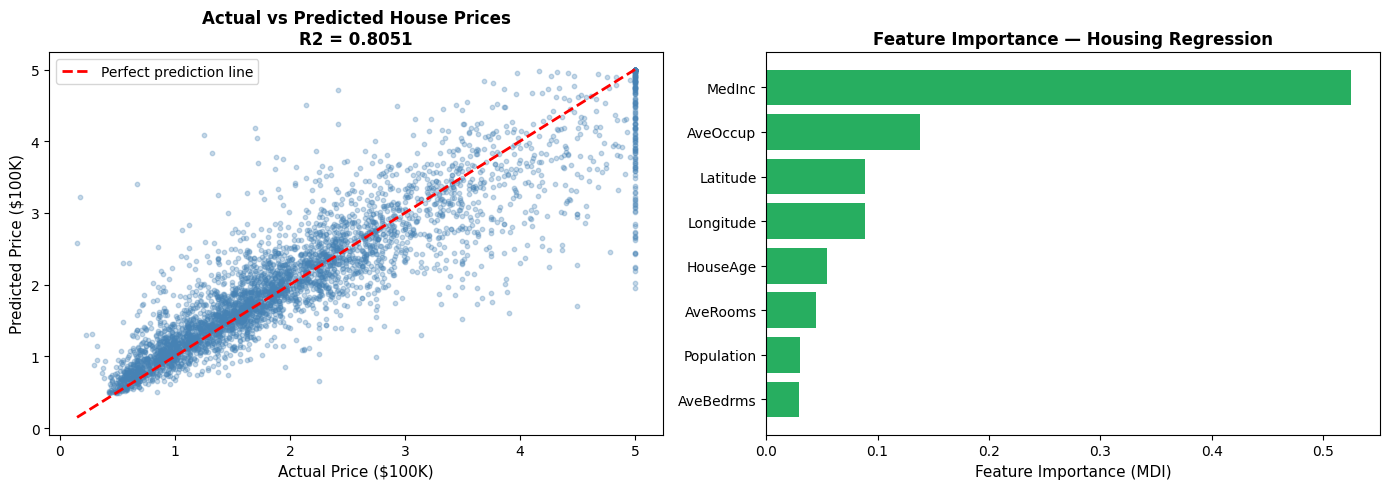


GFG Note: MedInc (median income) is consistently the most important
feature for predicting house price — intuitive and consistent with data.


In [21]:
# Step 16: Random Forest Regression — House Price Prediction (GFG)
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# GFG uses California Housing as the regression example
housing = fetch_california_housing()
X_reg = pd.DataFrame(housing.data, columns=housing.feature_names)
y_reg = housing.target  # median house value in $100K units

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

rfr = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True, n_jobs=-1)
rfr.fit(X_tr_r, y_tr_r)
y_pred_r = rfr.predict(X_te_r)

mse  = mean_squared_error(y_te_r, y_pred_r)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_te_r, y_pred_r)
r2   = r2_score(y_te_r, y_pred_r)

print('Random Forest Regression — California Housing (GFG example)')
print('=' * 55)
print(f'MSE        : {mse:.4f}')
print(f'RMSE       : {rmse:.4f}  (in $100K units)')
print(f'MAE        : {mae:.4f}  (in $100K units)')
print(f'R2 Score   : {r2:.4f}  (1.0 = perfect, 0.0 = no better than mean)')
print(f'OOB R2     : {rfr.oob_score_:.4f}  (free validation estimate)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_te_r, y_pred_r, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_te_r.min(), y_te_r.max()], [y_te_r.min(), y_te_r.max()],
             'r--', linewidth=2, label='Perfect prediction line')
axes[0].set_xlabel('Actual Price ($100K)', fontsize=11)
axes[0].set_ylabel('Predicted Price ($100K)', fontsize=11)
axes[0].set_title(f'Actual vs Predicted House Prices\nR2 = {r2:.4f}', fontsize=12, fontweight='bold')
axes[0].legend()

# Feature importance
imp_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Importance': rfr.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(imp_df['Feature'], imp_df['Importance'], color='#27ae60')
axes[1].set_xlabel('Feature Importance (MDI)', fontsize=11)
axes[1].set_title('Feature Importance — Housing Regression', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nGFG Note: MedInc (median income) is consistently the most important')
print('feature for predicting house price — intuitive and consistent with data.')

---

## Master Cheat Sheet — Everything in One Place

| Concept | One-liner |
|---------|----------|
| Random Forest | Ensemble of Decision Trees trained on different bootstrap samples |
| Bagging | Bootstrap sampling + aggregation (vote/average) |
| Bootstrap | Sample WITH replacement — each tree sees ~63% unique rows |
| OOB Sample | ~37% rows a tree never saw — used as free validation |
| OOB Score | Accuracy on OOB samples — free substitute for cross-validation |
| Feature randomness | Each split considers only sqrt(n_features) features |
| n_estimators | Number of trees — more is always better until plateau |
| max_features | Features per split — 'sqrt' for classification |
| Feature Importance (MDI) | Avg impurity decrease across all trees where feature was used |
| Permutation Importance | Accuracy drop when feature values are shuffled — unbiased |
| Aggregation | Classification = majority vote; Regression = mean |
| class_weight='balanced' | Penalizes majority class — fixes imbalanced datasets |

---

## Hyperparameter Quick Reference

| Parameter | Default | What it controls | Tip |
|-----------|---------|-----------------|-----|
| `n_estimators` | 100 | Number of trees | Start 100-200; increase until OOB plateaus |
| `max_features` | 'sqrt' | Features per split | 'sqrt' for classification, n/3 for regression |
| `max_depth` | None | Max tree depth | None is fine — RF controls variance via averaging |
| `min_samples_leaf` | 1 | Min samples per leaf | Increase (e.g., 5) on noisy data |
| `min_samples_split` | 2 | Min samples to split | Increase on very noisy data |
| `oob_score` | False | Compute OOB score | Always set True — free validation |
| `class_weight` | None | Class weighting | 'balanced' for imbalanced datasets |
| `n_jobs` | 1 | Parallel jobs | -1 to use all CPU cores |

---

## Quick Math Reference

```
Bootstrap inclusion probability : 1 - (1 - 1/N)^N  ≈  0.632  (for large N)
OOB fraction                    : ≈ 0.368
Default max_features (classif.) : sqrt(n_features)
Default max_features (regress.) : n_features / 3
Variance of ensemble            : σ² / n_estimators  (if trees are independent)
Feature importance (MDI)        : avg over trees of sum (n_node/N × delta_impurity)
```

---

## Random Forest vs Gradient Boosting — When to Use Which?

| Situation | Use |
|-----------|-----|
| Good accuracy needed with minimal tuning | Random Forest |
| Best possible accuracy, willing to tune | Gradient Boosting (XGBoost/LightGBM) |
| Large dataset, fast training needed | Random Forest (parallelizable) |
| Need to explain prediction path | Single Decision Tree |
| Imbalanced classes | Both with class_weight='balanced' |
| Noisy data | Random Forest (more robust) |

---

## Decision Tree vs Random Forest — Quick Comparison

| Property | Decision Tree | Random Forest |
|----------|--------------|---------------|
| Interpretable? | Yes — see every rule | No — black box |
| Overfitting risk | High | Low |
| Training speed | Fast | Slower (x100 trees) |
| Prediction speed | Fast (O log N) | Slower (x100 trees) |
| Feature importance | Yes | Yes (more reliable) |
| Needs scaling? | No | No |
| Best for | Explainability | Accuracy |